# Relación entre nitratos/fosfatos y boyas

In [1]:
import pandas as pd
from utils import *
import matplotlib.pyplot as plt
import os
from statsmodels.graphics.tsaplots import plot_ccf
import matplotlib.pyplot as plt

## Nitratos y fosfatos

Cargamos los datos del Canal Mar Menor

El dataset presenta varios problemas: (i) Hay observaciones que tienen dos fechas, como 25-26/05/2022; (ii) Hay observaciones que no tienen fecha; (iii) Hay observaciones que no tienen ningún valor; (iv) Hay strings en los campos que deberían haber números.

In [277]:
# Definir el nombre del archivo y las hojas de interés con sus respectivos rangos de columnas
filename = "Registro_Ramblas_MARMENOR.xlsx"
sheet_info = {
    "Caudal": range(1, 26),
    "Nitratos": range(1, 25),
    "Fosfatos": range(1, 25),
    # "Conductividad": range(1, 25),
    # "NitratosDiario": range(1, 14),
    # "FosfatosDiario": range(1, 14)
}

# Función para cargar y procesar cada hoja
def load_and_process_sheet(sheet_name, usecols):
    # Cargar el dataframe de la hoja con las columnas especificadas
    df = pd.read_excel(filename, sheet_name=sheet_name, skiprows=6, usecols=usecols).dropna(how="all") 
    # Procesar el dataframe: extraer fechas, eliminar NaNs, reemplazar valores
    df['Fecha'] = df['Fecha'].apply(extract_recent_date)
    df = df[~df['Fecha'].isna()]
    df = df.fillna(0)
    df = df.applymap(replace_strings)
    return df

# Cargar y procesar todos los dataframes en un diccionario con nombres como claves
dataframes = {name: load_and_process_sheet(name, cols) for name, cols in sheet_info.items()}


Los puntos que nos interesan a priori son para las boyas CTD7 y 9, que son las más cercanas a las ubicaciones que desembocan al Mar.

Para CTD7: Valla Militar, Venta Simón, Freático los Alcázares, Rambla del Albujón, Aliviadero Estación de Bombeo, Obra de paso bajo carretera Los Urrutia, Desembocadura Rambla de Miranda, Desembocadura Rambla del Miedo.

Para CTD9: Desembocadura Rambla de Matildes, Rambla de las Matildes Corriente Sur, Lo Poyo.

Vemos la cantidad de valores de cada ubicación que no son 0's

In [278]:
(1-(dataframes["Caudal"] == 0).sum()/dataframes["Caudal"].shape[0]).round(2)

Fecha                                      1.00
Total desaguado por rambla Albujón         0.98
Drenaje Los Alcázares                      0.01
Desembocadura rambla Albujón               0.94
Aguas arriba Barrio de la Fuensanta        0.02
Badén aguas abajo La Puebla                0.02
Pasaje la balsa                            0.02
EDAR Torre-Pacheco                         0.00
Tuberías salmuera bajo N-332               0.00
Canal D-7                                  0.95
Azud CHS                                   0.00
Tramo Medio Rambla Albujón                 0.22
Surgencia                                  0.00
Aliviadero                                 0.15
Obra de paso bajo carretera Los Urrutia    0.64
Desembocadura rambla de Miranda            0.21
Desembocadura rambla del Miedo             0.00
El Carmolí                                 0.00
Desembocadura rambla de las Matildes       0.08
Rambla de las Matildes - corriente sur     0.88
Lo Poyo                                 

De acuerdo eso, decidimos quedarnos únicamente con las siguientes ubicaciones para las boyas:
- CTD7: Desembocadura rambla Albujón, Freático los Alcázares (?), Obra de paso bajo carretera Los Urrutia.
- CTD9: Rambla de las Matildes - corriente sur, Lo Poyo.

In [280]:
# Filtrar las columnas en el diccionario de dataframes
cols_to_keep = ["Fecha", "Desembocadura rambla Albujón", "Obra de paso bajo carretera Los Urrutia", "Rambla de las Matildes - corriente sur", "Lo Poyo"]

for name, df in dataframes.items():
    # Mantener solo las columnas especificadas que existen en cada dataframe
    existing_cols = df.columns.intersection(cols_to_keep)
    dataframes[name] = df.loc[:, existing_cols]

In [295]:
df1 = dataframes['Caudal'].set_index('Fecha')
df2 = dataframes['Nitratos'].set_index('Fecha')

# Alinear los dataframes por el índice de "Fecha" usando align, con inner join para mantener solo fechas comunes
aligned_df1, aligned_df2 = df1.align(df2, join='inner')

df_nitratos_diario = pd.DataFrame(index=aligned_df1.index)

for col in aligned_df1.columns:
    df_nitratos_diario[col] = aligned_df1[col] * aligned_df2[col] * 86400/1e6

dataframes['Nitratos Diario'] = df_nitratos_diario.reset_index()

In [296]:
df1 = dataframes['Caudal'].set_index('Fecha')
df2 = dataframes['Fosfatos'].set_index('Fecha')

# Alinear los dataframes por el índice de "Fecha" usando align, con inner join para mantener solo fechas comunes
aligned_df1, aligned_df2 = df1.align(df2, join='inner')

df_fosfatos_diario = pd.DataFrame(index=aligned_df1.index)

for col in aligned_df1.columns:
    df_fosfatos_diario[col] = aligned_df1[col] * aligned_df2[col] * 86400/1e6

dataframes['Fosfatos Diario'] = df_fosfatos_diario.reset_index()

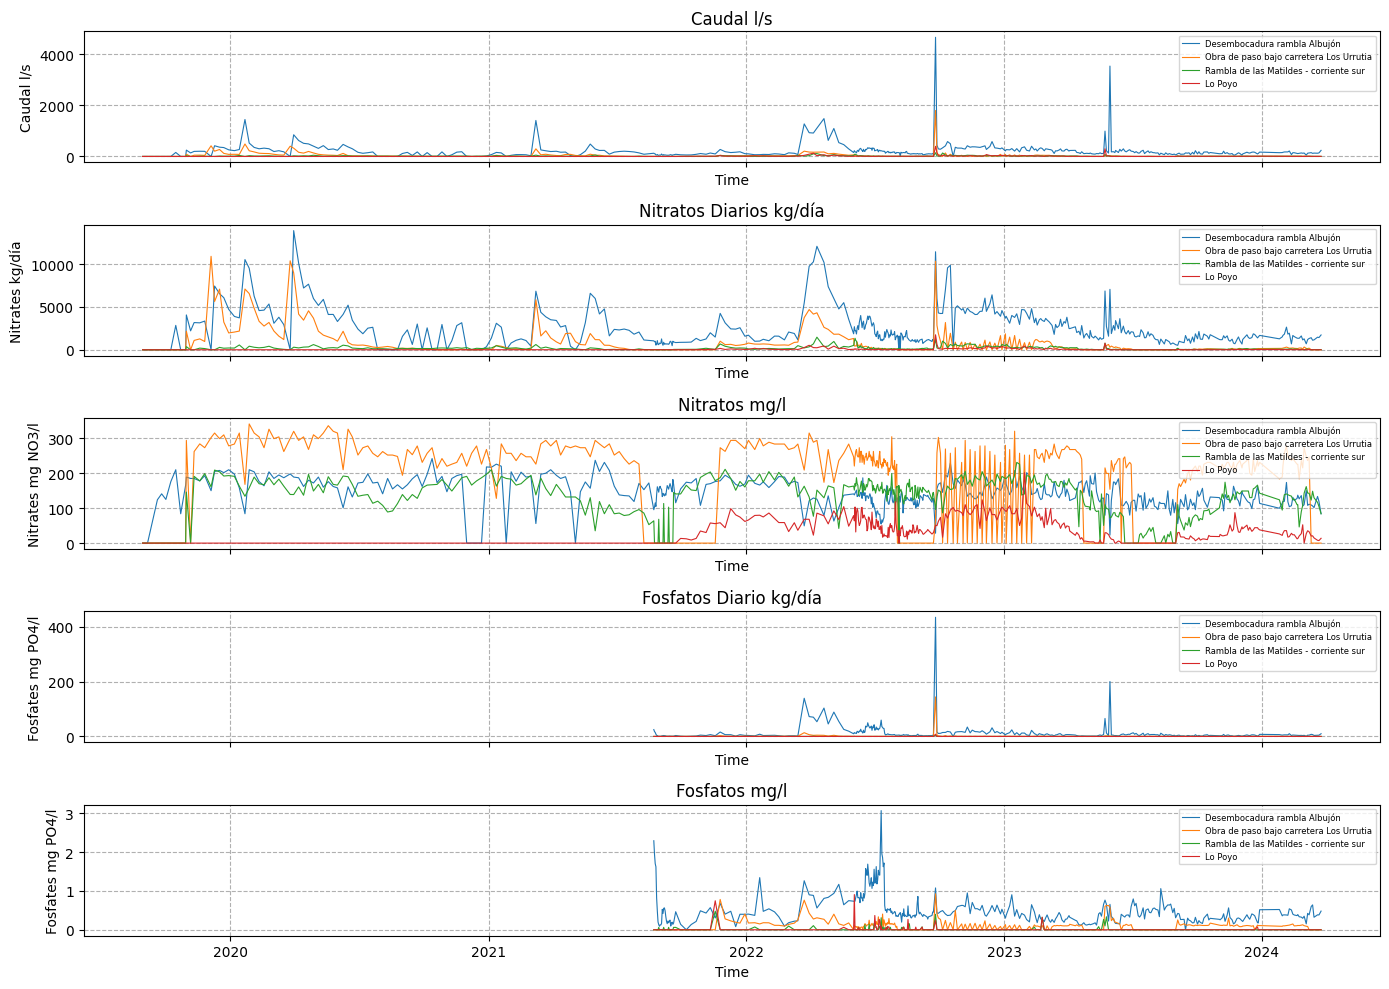

In [304]:
fig, ax = plt.subplots(figsize=(14, 10), nrows=5, ncols=1, sharex=True)

# Plots
# Caudal
for col in dataframes["Caudal"].columns[1:]:
    ax[0].plot(dataframes["Caudal"]["Fecha"], dataframes["Caudal"][col], label=f"{col}", linewidth=0.8)
ax[0].legend(loc="upper right", fontsize=6)
ax[0].set_ylabel("Caudal l/s")
ax[0].set_xlabel("Time")
ax[0].grid(linestyle='--')
ax[0].set_title("Caudal l/s")

# Nitratos Diario
for col in dataframes["Nitratos Diario"].columns[1:]:
    ax[1].plot(dataframes["Nitratos Diario"]["Fecha"], dataframes["Nitratos Diario"][col], label=f"{col}", linewidth=0.8)
ax[1].legend(loc="upper right", fontsize=6)
ax[1].set_ylabel("Nitrates kg/día")
ax[1].set_xlabel("Time")
ax[1].grid(linestyle='--')
ax[1].set_title("Nitratos Diarios kg/día")

# Nitratos
for col in dataframes["Nitratos"].columns[1:]:
    ax[2].plot(dataframes["Nitratos"]["Fecha"], dataframes["Nitratos"][col], label=f"{col}", linewidth=0.8)
ax[2].legend(loc="upper right", fontsize=6)
ax[2].set_ylabel("Nitrates mg NO3/l")
ax[2].set_xlabel("Time")
ax[2].grid(linestyle='--')
ax[2].set_title("Nitratos mg/l")

# Fosfatos
for col in dataframes["Fosfatos Diario"].columns[1:]:
    ax[3].plot(dataframes["Fosfatos Diario"]["Fecha"], dataframes["Fosfatos Diario"][col], label=f"{col}", linewidth=0.8)
ax[3].legend(loc="upper right", fontsize=6)
ax[3].set_ylabel("Fosfates mg PO4/l")
ax[3].set_xlabel("Time")
ax[3].grid(linestyle='--')
ax[3].set_title("Fosfatos Diario kg/día")

# Fosfatos
for col in dataframes["Fosfatos"].columns[1:]:
    ax[4].plot(dataframes["Fosfatos"]["Fecha"], dataframes["Fosfatos"][col], label=f"{col}", linewidth=0.8)
ax[4].legend(loc="upper right", fontsize=6)
ax[4].set_ylabel("Fosfates mg PO4/l")
ax[4].set_xlabel("Time")
ax[4].grid(linestyle='--')
ax[4].set_title("Fosfatos mg/l")


fig.tight_layout()
plt.show()


### Series interpoladas

In [307]:
# Crear una copia del diccionario de dataframes
dataframes_interpolados = {name: df.copy() for name, df in dataframes.items()}

for name, df in dataframes_interpolados.items():
    # Reemplazar 0 por NaN en todas las columnas excepto 'Fecha'
    dataframes_interpolados[name].loc[:, df.columns != 'Fecha'] = df.loc[:, df.columns != 'Fecha'].replace(0, np.nan)

dataframes_interpolados = {key: df for key, df in dataframes_interpolados.items() if key in ['Caudal', 'Nitratos', 'Fosfatos', 'Nitratos Diario', 'Fosfatos Diario']}

Sobre los parámetros de ARIMA:
- p: orden autorregresivo. Número de valores previos de la serie para hacer la predicción
- d: orden de diferenciación. Número de veces que la serie se diferencia para hacerla estacionaria. La diferenciación es Y(t) - Y(t-1)
- q: orden de media móvil. Número de errores pasados que se utilizan para modelar el valor actual de Y(t) 

In [308]:
from statsmodels.tsa.arima.model import ARIMA

# Función para predecir valores nulos usando ARIMA
def fill_missing_arima(df,col):
    #series = series.copy()
    temp_df = df.copy()
    series = temp_df[col]
    # Rellenar valores nulos usando un modelo ARIMA
    is_null = series.isnull()
    if is_null.any():
        model = ARIMA(series.dropna(), order=(1, 0, 1))  # Ajusta los parámetros de ARIMA según tus datos
        # Parametros p, q ,d
        #
        model_fit = model.fit()
        series[is_null] = model_fit.predict(start=is_null.index[0], end=is_null.index[-1])
    return series

# Aplicar el modelo ARIMA en cada columna de cada dataframe
for name, df in dataframes_interpolados.items():
    for col in df.columns:
        if col != 'Fecha':
            df[col] = fill_missing_arima(df, col)


/home/antonio/.pyenv/versions/3.8.5/envs/nitrates/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/antonio/.pyenv/versions/3.8.5/envs/nitrates/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/antonio/.pyenv/versions/3.8.5/envs/nitrates/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/antonio/.pyenv/versions/3.8.5/envs/nitrates/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/an

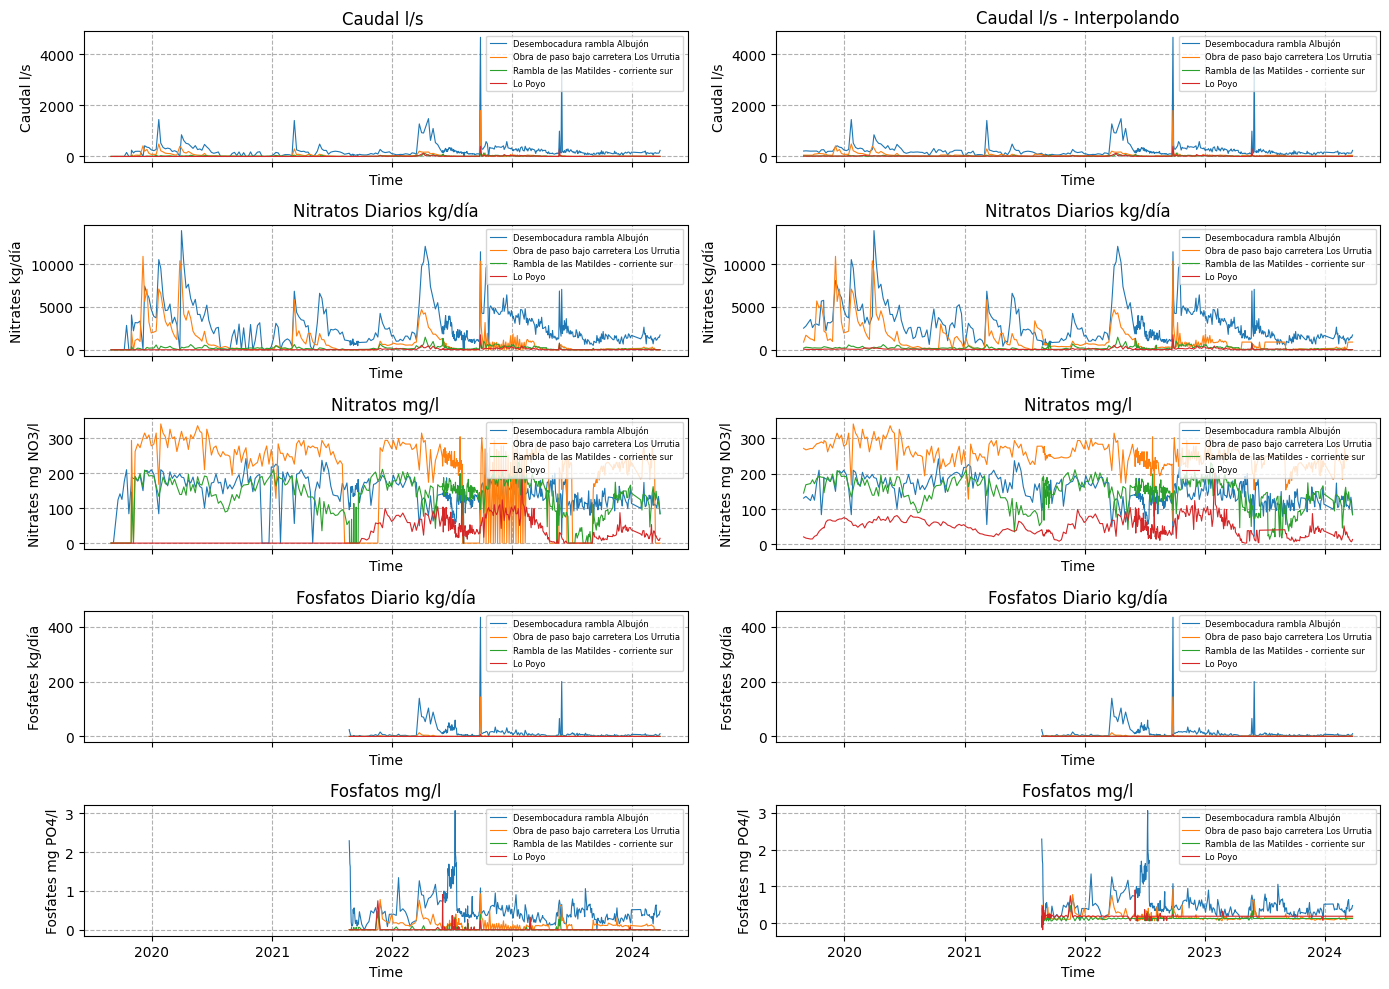

In [310]:
fig, ax = plt.subplots(figsize=(14, 10), nrows=5, ncols=2, sharex=True)

# Plots
# Caudal
for col in dataframes["Caudal"].columns[1:]:
    ax[0, 0].plot(dataframes["Caudal"]["Fecha"], dataframes["Caudal"][col], label=f"{col}", linewidth=0.8)
ax[0, 0].legend(loc="upper right", fontsize=6)
ax[0, 0].set_ylabel("Caudal l/s")
ax[0, 0].set_xlabel("Time")
ax[0, 0].grid(linestyle='--')
ax[0, 0].set_title("Caudal l/s ")

for col in dataframes_interpolados["Caudal"].columns[1:]:
    ax[0, 1].plot(dataframes_interpolados["Caudal"]["Fecha"], dataframes_interpolados["Caudal"][col], label=f"{col}", linewidth=0.8)
ax[0, 1].legend(loc="upper right", fontsize=6)
ax[0, 1].set_ylabel("Caudal l/s")
ax[0, 1].set_xlabel("Time")
ax[0, 1].grid(linestyle='--')
ax[0, 1].set_title("Caudal l/s - Interpolando")

# Nitratos Diario
for col in dataframes["Nitratos Diario"].columns[1:]:
    ax[1, 0].plot(dataframes["Nitratos Diario"]["Fecha"], dataframes["Nitratos Diario"][col], label=f"{col}", linewidth=0.8)
ax[1, 0].legend(loc="upper right", fontsize=6)
ax[1, 0].set_ylabel("Nitrates kg/día")
ax[1, 0].set_xlabel("Time")
ax[1, 0].grid(linestyle='--')
ax[1, 0].set_title("Nitratos Diarios kg/día")

for col in dataframes_interpolados["Nitratos Diario"].columns[1:]:
    ax[1, 1].plot(dataframes_interpolados["Nitratos Diario"]["Fecha"], dataframes_interpolados["Nitratos Diario"][col], label=f"{col}", linewidth=0.8)
ax[1, 1].legend(loc="upper right", fontsize=6)
ax[1, 1].set_ylabel("Nitrates kg/día")
ax[1, 1].set_xlabel("Time")
ax[1, 1].grid(linestyle='--')
ax[1, 1].set_title("Nitratos Diarios kg/día")

# Nitratos
for col in dataframes["Nitratos"].columns[1:]:
    ax[2, 0].plot(dataframes["Nitratos"]["Fecha"], dataframes["Nitratos"][col], label=f"{col}", linewidth=0.8)
ax[2, 0].legend(loc="upper right", fontsize=6)
ax[2, 0].set_ylabel("Nitrates mg NO3/l")
ax[2, 0].set_xlabel("Time")
ax[2, 0].grid(linestyle='--')
ax[2, 0].set_title("Nitratos mg/l")

for col in dataframes_interpolados["Nitratos"].columns[1:]:
    ax[2, 1].plot(dataframes_interpolados["Nitratos"]["Fecha"], dataframes_interpolados["Nitratos"][col], label=f"{col}", linewidth=0.8)
ax[2, 1].legend(loc="upper right", fontsize=6)
ax[2, 1].set_ylabel("Nitrates mg NO3/l")
ax[2, 1].set_xlabel("Time")
ax[2, 1].grid(linestyle='--')
ax[2, 1].set_title("Nitratos mg/l")

# Fosfatos Diario
for col in dataframes["Fosfatos Diario"].columns[1:]:
    ax[3, 0].plot(dataframes["Fosfatos Diario"]["Fecha"], dataframes["Fosfatos Diario"][col], label=f"{col}", linewidth=0.8)
ax[3, 0].legend(loc="upper right", fontsize=6)
ax[3, 0].set_ylabel("Fosfates kg/día")
ax[3, 0].set_xlabel("Time")
ax[3, 0].grid(linestyle='--')
ax[3, 0].set_title("Fosfatos Diario kg/día")

for col in dataframes_interpolados["Fosfatos Diario"].columns[1:]:
    ax[3, 1].plot(dataframes_interpolados["Fosfatos Diario"]["Fecha"], dataframes_interpolados["Fosfatos Diario"][col], label=f"{col}", linewidth=0.8)
ax[3, 1].legend(loc="upper right", fontsize=6)
ax[3, 1].set_ylabel("Fosfates kg/día")
ax[3, 1].set_xlabel("Time")
ax[3, 1].grid(linestyle='--')
ax[3, 1].set_title("Fosfatos Diario kg/día")

# Fosfatos
for col in dataframes["Fosfatos"].columns[1:]:
    ax[4, 0].plot(dataframes["Fosfatos"]["Fecha"], dataframes["Fosfatos"][col], label=f"{col}", linewidth=0.8)
ax[4, 0].legend(loc="upper right", fontsize=6)
ax[4, 0].set_ylabel("Fosfates mg PO4/l")
ax[4, 0].set_xlabel("Time")
ax[4, 0].grid(linestyle='--')
ax[4, 0].set_title("Fosfatos mg/l")

for col in dataframes_interpolados["Fosfatos"].columns[1:]:
    ax[4, 1].plot(dataframes_interpolados["Fosfatos"]["Fecha"], dataframes_interpolados["Fosfatos"][col], label=f"{col}", linewidth=0.8)
ax[4, 1].legend(loc="upper right", fontsize=6)
ax[4, 1].set_ylabel("Fosfates mg PO4/l")
ax[4, 1].set_xlabel("Time")
ax[4, 1].grid(linestyle='--')
ax[4, 1].set_title("Fosfatos mg/l")

fig.tight_layout()
plt.show()


## Boyas CTD7 y 9

In [311]:
# Ruta a la carpeta que contiene todas las boyas
path = "boyaUPCT/extractedData/"
# Listamos los nombres de todas las boyas
buoy_ids = ["CTD7", "CTD9"]#[f for f in os.listdir(path) if os.path.isdir(os.path.join(path, f))]
# Diccionario para guardar dataframes
dataframes_boyas = {}

# Para cada boya cargamos todos sus csvs y los guardamos con key f"{bouy_id}_{variable}"
for buoy_id in buoy_ids:
    archivos_csv = [f for f in os.listdir(path + buoy_id) if f.endswith('.csv')]
    
    # Leer cada archivo CSV y guardar el DataFrame en el diccionario con el mismo nombre que el archivo (sin la extensión)
    for archivo in archivos_csv:
        if archivo == "Transparency.csv":
            continue
        
        nombre_variable = os.path.splitext(archivo)[0]
        ruta_completa = os.path.join(path, buoy_id, archivo)
        dataframes_boyas[f"{buoy_id}_{nombre_variable}"] = pd.read_csv(ruta_completa)

In [325]:
dataframes_interpolados["Nitratos Diario"]['Nitratos CTD7'] = dataframes_interpolados["Nitratos Diario"].loc[:, ["Desembocadura rambla Albujón", "Obra de paso bajo carretera Los Urrutia"]].sum(axis=1)
dataframes_interpolados["Nitratos Diario"]['Nitratos CTD9'] = dataframes_interpolados["Nitratos Diario"].loc[:, ["Rambla de las Matildes - corriente sur", "Lo Poyo"]].sum(axis=1)
dataframes_interpolados["Fosfatos Diario"]['Fosfatos CTD7'] = dataframes_interpolados["Fosfatos Diario"].loc[:, ["Desembocadura rambla Albujón", "Obra de paso bajo carretera Los Urrutia"]].sum(axis=1)
dataframes_interpolados["Fosfatos Diario"]['Fosfatos CTD9'] = dataframes_interpolados["Fosfatos Diario"].loc[:, ["Rambla de las Matildes - corriente sur", "Lo Poyo"]].sum(axis=1)
dataframes_interpolados["Nitratos"]['Nitratos CTD7'] = dataframes_interpolados["Nitratos"].loc[:, ["Desembocadura rambla Albujón", "Obra de paso bajo carretera Los Urrutia"]].sum(axis=1)
dataframes_interpolados["Nitratos"]['Nitratos CTD9'] = dataframes_interpolados["Nitratos"].loc[:, ["Rambla de las Matildes - corriente sur", "Lo Poyo"]].sum(axis=1)
dataframes_interpolados["Fosfatos"]['Fosfatos CTD7'] = dataframes_interpolados["Fosfatos"].loc[:, ["Desembocadura rambla Albujón", "Obra de paso bajo carretera Los Urrutia"]].sum(axis=1)
dataframes_interpolados["Fosfatos"]['Fosfatos CTD9'] = dataframes_interpolados["Fosfatos"].loc[:, ["Rambla de las Matildes - corriente sur", "Lo Poyo"]].sum(axis=1)

### Boya CTD7 - Nitratos/Fosfatos

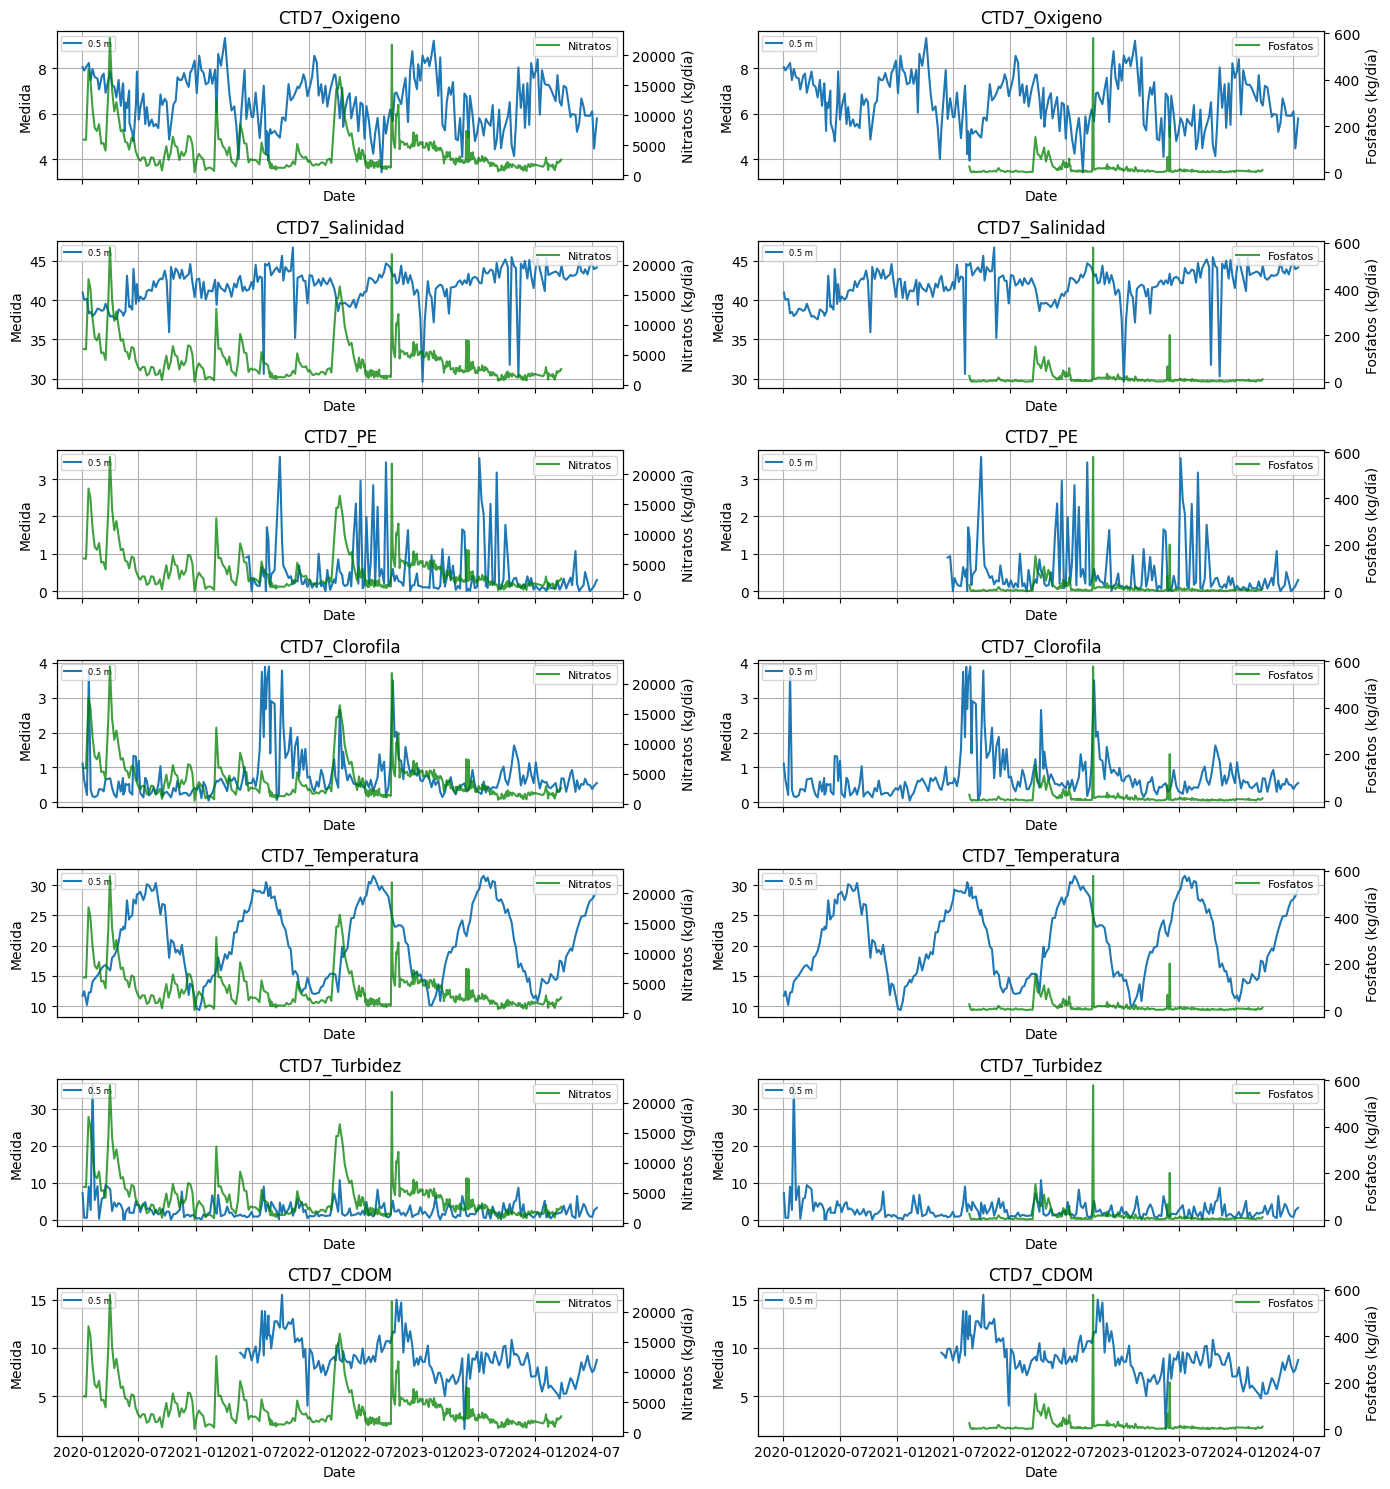

In [316]:
dataframes_CTD7 = {k: v for k, v in dataframes_boyas.items() if "CTD7" in k}

fig, ax = plt.subplots(figsize=(14, 6 * 2.5), nrows=7, ncols=2, sharex=True)

# Iterar sobre cada DataFrame y su correspondiente subplot
for i, (nombre, df) in enumerate(dataframes_CTD7.items()):
    # Convertir la columna 'Date' a datetime y filtrar desde 2020 en adelante
    df['Date'] = pd.to_datetime(df['Date'])
    df_filtered = df[df['Date'] >= '2020-01-01']
    
    # Filtrar nitratos y fosfatos desde 2020 en adelante
    nitratos_filtered = dataframes_interpolados["Nitratos Diario"][dataframes_interpolados["Nitratos Diario"]["Fecha"] >= '2020-01-01']
    fosfatos_filtered = dataframes_interpolados["Fosfatos Diario"][dataframes_interpolados["Fosfatos Diario"]["Fecha"] >= '2020-01-01']
    # nitratos_filtered = dataframes_interpolados["Nitratos"][dataframes_interpolados["Nitratos"]["Fecha"] >= '2020-01-01']
    # fosfatos_filtered = dataframes_interpolados["Fosfatos"][dataframes_interpolados["Fosfatos"]["Fecha"] >= '2020-01-01']
    # Graficar la columna de profundidad (ejemplo usando una profundidad específica)
    depths = ["0.5"]
    for depth in depths:
        ax[i, 0].plot(df_filtered['Date'], df_filtered[depth], label=f'{depth} m')

    ax[i, 0].set_title(nombre)
    ax[i, 0].set_xlabel('Date')
    ax[i, 0].set_ylabel('Medida')
    ax[i, 0].legend(loc='upper left', fontsize=6)
    ax[i, 0].grid(True)

    # Añadir el gráfico de nitratos en el eje y secundario
    ax2 = ax[i, 0].twinx()
    ax2.plot(nitratos_filtered["Fecha"], nitratos_filtered["Nitratos CTD7"], label="Nitratos", color="green", alpha=0.75)
    ax2.set_ylabel("Nitratos (kg/día)")
    ax2.legend(loc="upper right", fontsize=8)

    # Graficar fosfatos en la segunda columna de subplots
    for depth in depths:
        ax[i, 1].plot(df_filtered['Date'], df_filtered[depth], label=f'{depth} m')

    ax[i, 1].set_title(nombre)
    ax[i, 1].set_xlabel('Date')
    ax[i, 1].set_ylabel('Medida')
    ax[i, 1].legend(loc='upper left', fontsize=6)
    ax[i, 1].grid(True)

    # Añadir el gráfico de fosfatos en el eje y secundario
    ax2 = ax[i, 1].twinx()
    ax2.plot(fosfatos_filtered["Fecha"], fosfatos_filtered["Fosfatos CTD7"], label="Fosfatos", color="green", alpha=0.75)
    ax2.set_ylabel("Fosfatos (kg/día)")
    ax2.legend(loc="upper right", fontsize=8)

# Ajuste de layout
fig.tight_layout()
plt.show()


### Boya CTD9 - Nitratos/Fosfatos

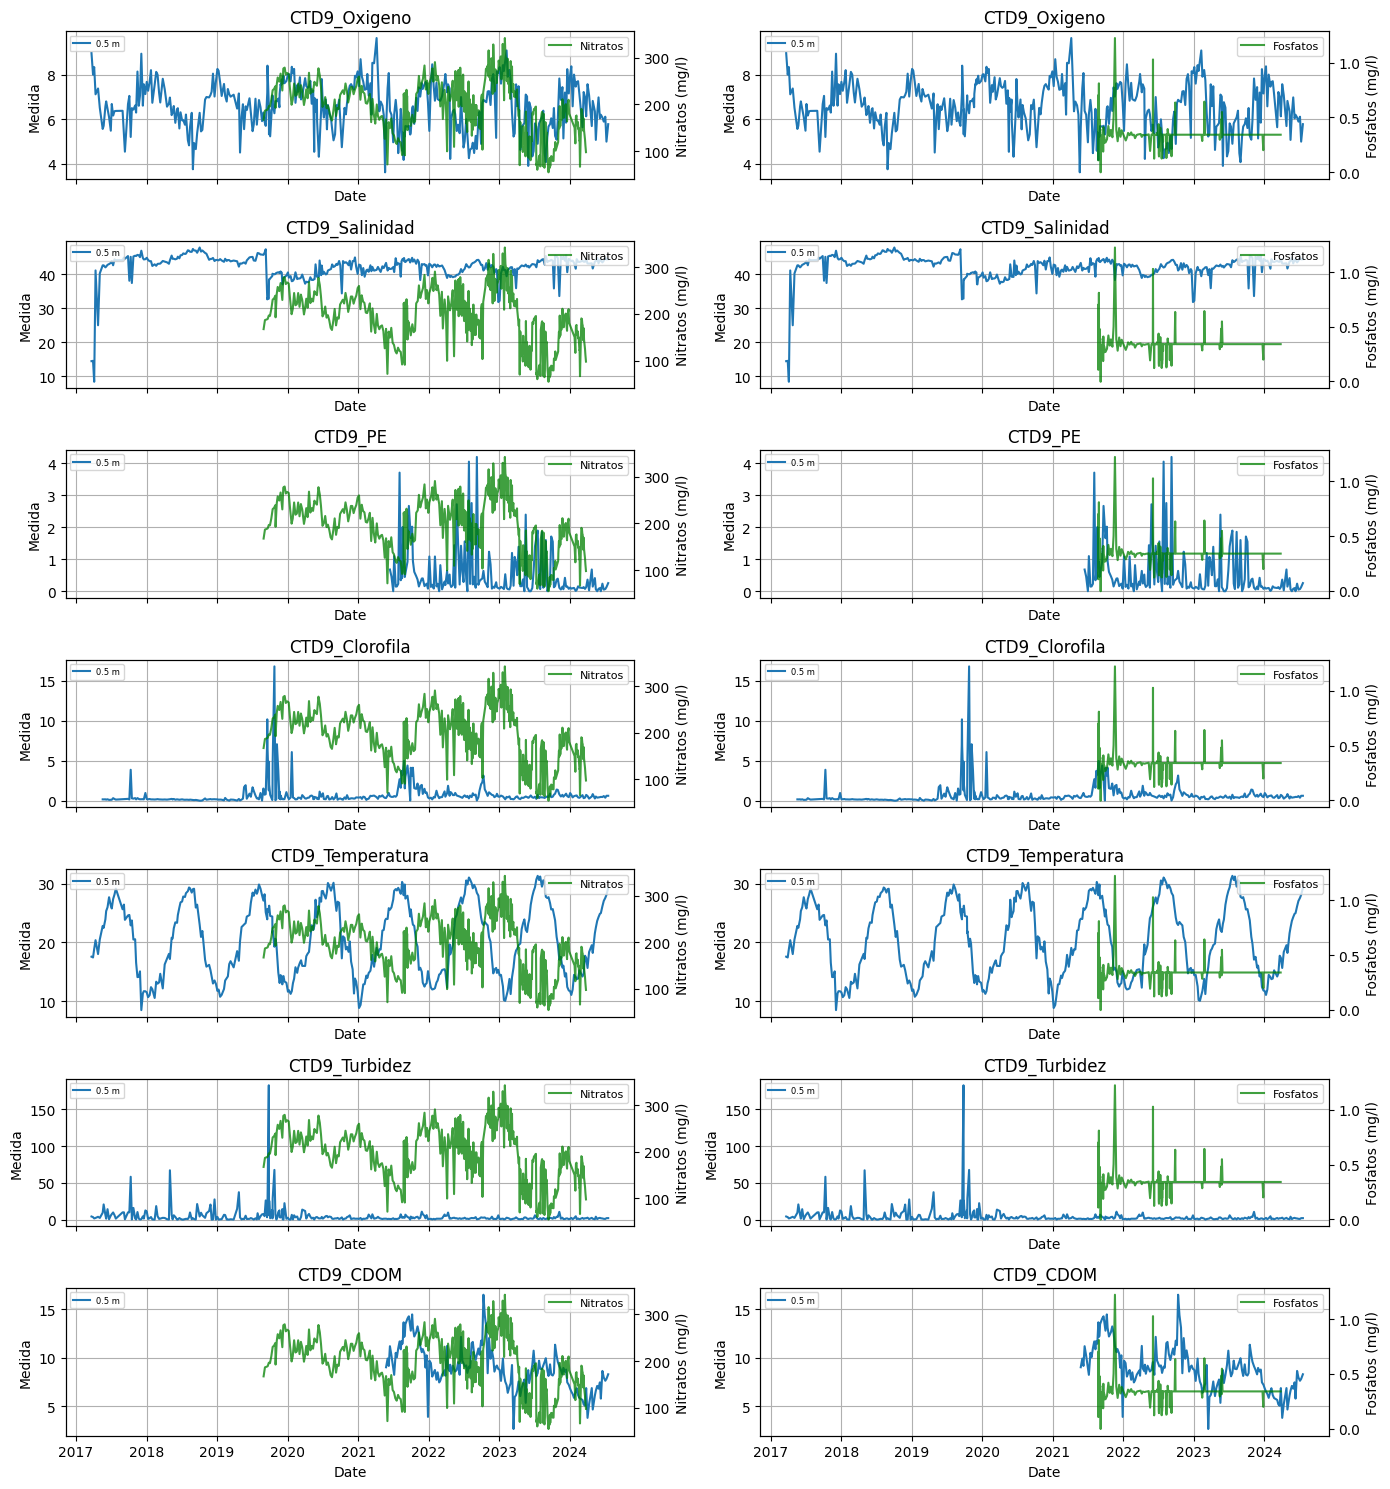

In [198]:
dataframes_CTD9 = {k: v for k, v in dataframes_boyas.items() if "CTD9" in k}

fig, ax = plt.subplots(figsize=(14, 6 * 2.5), nrows=7, ncols=2, sharex=True)

# Iterar sobre cada DataFrame y su correspondiente subplot
for i, (nombre, df) in enumerate(dataframes_CTD9.items()):
    # Convertir la columna 'Date' a datetime
    df['Date'] = pd.to_datetime(df['Date'])
    
    # Graficar la columna de profundidad (ejemplo usando una profundidad específica)
    depths = ["0.5"]
    for depth in depths:
        ax[i,0].plot(df['Date'], df[depth], label=f'{depth} m')

    ax[i,0].set_title(nombre)
    ax[i,0].set_xlabel('Date')
    ax[i,0].set_ylabel('Medida')
    ax[i,0].legend(loc='upper left', fontsize=6)
    ax[i,0].grid(True)

    ax2 = ax[i,0].twinx()
    ax2.plot(dataframes_interpolados["Nitratos"]["Fecha"], dataframes_interpolados["Nitratos"]["Nitratos CTD9"], label="Nitratos", color="green", alpha=0.75)
    #ax2.plot(dataframes_interpolados["Nitratos"]["Fecha"], dataframes_interpolados["Nitratos"]["Obra de paso bajo carretera Los Urrutia"], label="Nitratos", color="orange", alpha=0.75)
    ax2.set_ylabel("Nitratos (mg/l)")
    ax2.legend(loc="upper right", fontsize=8)


    for depth in depths:
        ax[i,1].plot(df['Date'], df[depth], label=f'{depth} m')

    ax[i,1].set_title(nombre)
    ax[i,1].set_xlabel('Date')
    ax[i,1].set_ylabel('Medida')
    ax[i,1].legend(loc='upper left', fontsize=6)
    ax[i,1].grid(True)

    ax2 = ax[i,1].twinx()
    ax2.plot(dataframes_interpolados["Fosfatos"]["Fecha"], dataframes_interpolados["Fosfatos"]["Fosfatos CTD9"], label="Fosfatos", color="green", alpha=0.75)
    #ax2.plot(dataframes_interpolados["Nitratos"]["Fecha"], dataframes_interpolados["Nitratos"]["Obra de paso bajo carretera Los Urrutia"], label="Nitratos", color="orange", alpha=0.75)
    ax2.set_ylabel("Fosfatos (mg/l)")
    ax2.legend(loc="upper right", fontsize=8)

fig.tight_layout()


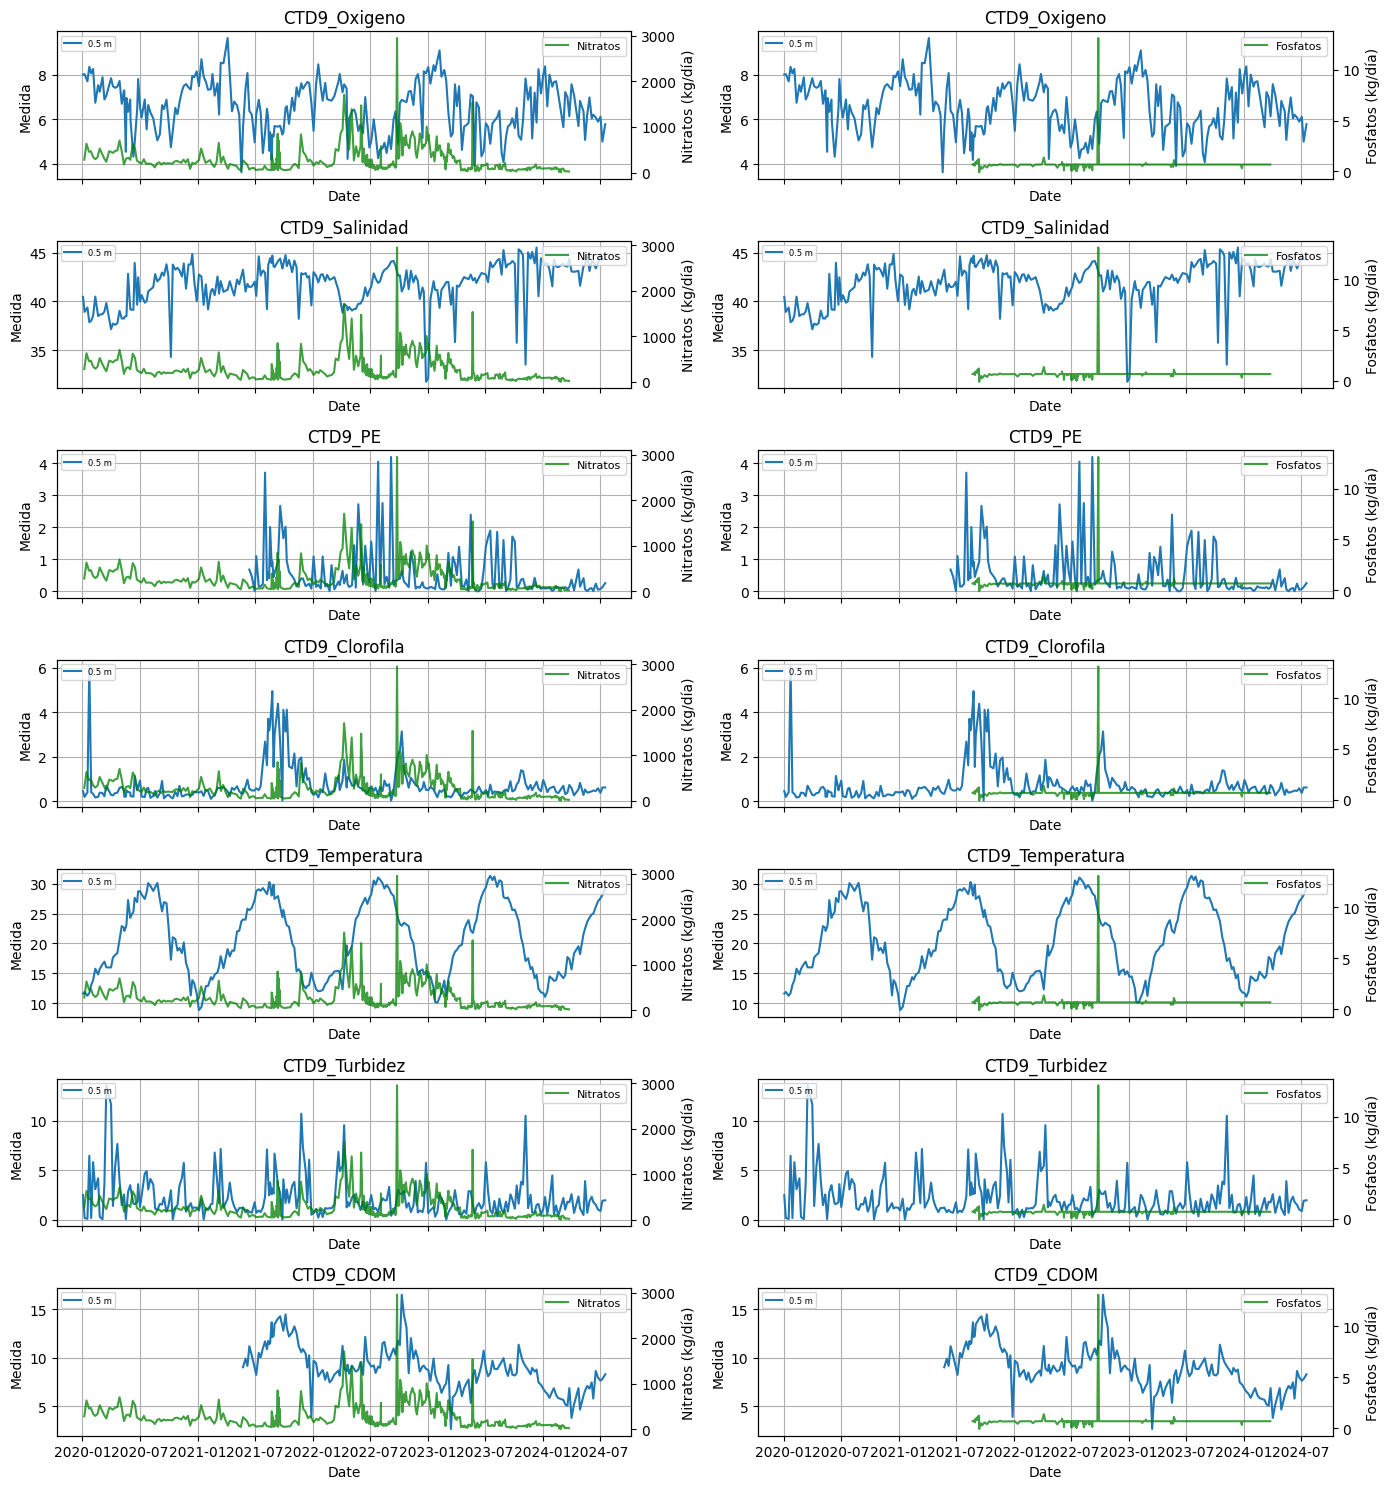

In [317]:
dataframes_CTD9 = {k: v for k, v in dataframes_boyas.items() if "CTD9" in k}

fig, ax = plt.subplots(figsize=(14, 6 * 2.5), nrows=7, ncols=2, sharex=True)

# Iterar sobre cada DataFrame y su correspondiente subplot
for i, (nombre, df) in enumerate(dataframes_CTD9.items()):
    # Convertir la columna 'Date' a datetime y filtrar desde 2020 en adelante
    df['Date'] = pd.to_datetime(df['Date'])
    df_filtered = df[df['Date'] >= '2020-01-01']
    
    # Filtrar nitratos y fosfatos desde 2020 en adelante
    nitratos_filtered = dataframes_interpolados["Nitratos Diario"][dataframes_interpolados["Nitratos Diario"]["Fecha"] >= '2020-01-01']
    fosfatos_filtered = dataframes_interpolados["Fosfatos Diario"][dataframes_interpolados["Fosfatos Diario"]["Fecha"] >= '2020-01-01']
    # nitratos_filtered = dataframes_interpolados["Nitratos"][dataframes_interpolados["Nitratos"]["Fecha"] >= '2020-01-01']
    # fosfatos_filtered = dataframes_interpolados["Fosfatos"][dataframes_interpolados["Fosfatos"]["Fecha"] >= '2020-01-01']

    # Graficar la columna de profundidad (ejemplo usando una profundidad específica)
    depths = ["0.5"]
    for depth in depths:
        ax[i, 0].plot(df_filtered['Date'], df_filtered[depth], label=f'{depth} m')

    ax[i, 0].set_title(nombre)
    ax[i, 0].set_xlabel('Date')
    ax[i, 0].set_ylabel('Medida')
    ax[i, 0].legend(loc='upper left', fontsize=6)
    ax[i, 0].grid(True)

    # Añadir el gráfico de nitratos en el eje y secundario
    ax2 = ax[i, 0].twinx()
    ax2.plot(nitratos_filtered["Fecha"], nitratos_filtered["Nitratos CTD9"], label="Nitratos", color="green", alpha=0.75)
    ax2.set_ylabel("Nitratos (kg/día)")
    ax2.legend(loc="upper right", fontsize=8)

    # Graficar fosfatos en la segunda columna de subplots
    for depth in depths:
        ax[i, 1].plot(df_filtered['Date'], df_filtered[depth], label=f'{depth} m')

    ax[i, 1].set_title(nombre)
    ax[i, 1].set_xlabel('Date')
    ax[i, 1].set_ylabel('Medida')
    ax[i, 1].legend(loc='upper left', fontsize=6)
    ax[i, 1].grid(True)

    # Añadir el gráfico de fosfatos en el eje y secundario
    ax2 = ax[i, 1].twinx()
    ax2.plot(fosfatos_filtered["Fecha"], fosfatos_filtered["Fosfatos CTD9"], label="Fosfatos", color="green", alpha=0.75)
    ax2.set_ylabel("Fosfatos (kg/día)")
    ax2.legend(loc="upper right", fontsize=8)

# Ajuste de layout
fig.tight_layout()
plt.show()


## Análisis estadístico

### Stationarity

In [203]:
from statsmodels.tsa.stattools import adfuller

In [318]:
def adf_test(series, title=''):
    result = adfuller(series.dropna(), autolag='AIC')  # dropna() para manejar valores faltantes
    print(f'ADF Statistic for {title}: {result[0]}')
    print(f'p-value for {title}: {result[1]}')
    #print(f'Critical Values for {title}: {result[4]}')
    if result[1] > 0.05:
        print(f"Series {title} is non-stationary.")
    else:
        print(f"Series {title} is stationary.")
    print('')

# Aplicar la prueba ADF a la columna "0.5" de cada dataframe en el diccionario
print("ADF Test for Original Series - Depth 0.5")
for nombre, df in dataframes_boyas.items():
    # Asegurarse de que la columna 'Date' esté en formato datetime
    df['Date'] = pd.to_datetime(df['Date'])
    
    # Comprobar la estacionariedad de la columna '0.5'
    if "0.5" in df.columns:
        adf_test(df["0.5"], title=f'{nombre} - Depth 0.5')

ADF Test for Original Series - Depth 0.5
ADF Statistic for CTD7_Oxigeno - Depth 0.5: -4.768020924234019
p-value for CTD7_Oxigeno - Depth 0.5: 6.258743258528964e-05
Series CTD7_Oxigeno - Depth 0.5 is stationary.

ADF Statistic for CTD7_Salinidad - Depth 0.5: -9.53145415153469
p-value for CTD7_Salinidad - Depth 0.5: 2.8833756197488065e-16
Series CTD7_Salinidad - Depth 0.5 is stationary.

ADF Statistic for CTD7_PE - Depth 0.5: -10.896908371702027
p-value for CTD7_PE - Depth 0.5: 1.18586578857116e-19
Series CTD7_PE - Depth 0.5 is stationary.

ADF Statistic for CTD7_Clorofila - Depth 0.5: -3.9723712188246023
p-value for CTD7_Clorofila - Depth 0.5: 0.001562297688757199
Series CTD7_Clorofila - Depth 0.5 is stationary.

ADF Statistic for CTD7_Temperatura - Depth 0.5: -8.116310262746087
p-value for CTD7_Temperatura - Depth 0.5: 1.1883975989623446e-12
Series CTD7_Temperatura - Depth 0.5 is stationary.

ADF Statistic for CTD7_Turbidez - Depth 0.5: -18.755748752414878
p-value for CTD7_Turbidez - D

In [319]:
for nombre, df in dataframes_interpolados.items():
    # Asegurarse de que la columna 'Date' esté en formato datetime
    df['Fecha'] = pd.to_datetime(df['Fecha'])
    
    for col in df.columns:
        adf_test(df[col], title=f'{nombre} - {col}')

ADF Statistic for Caudal - Fecha: 2.231151825064192
p-value for Caudal - Fecha: 0.9989071737928036
Series Caudal - Fecha is non-stationary.

ADF Statistic for Caudal - Desembocadura rambla Albujón: -8.99440102526228
p-value for Caudal - Desembocadura rambla Albujón: 6.755699086541863e-15
Series Caudal - Desembocadura rambla Albujón is stationary.

ADF Statistic for Caudal - Obra de paso bajo carretera Los Urrutia: -6.992870938557346
p-value for Caudal - Obra de paso bajo carretera Los Urrutia: 7.664644758415547e-10
Series Caudal - Obra de paso bajo carretera Los Urrutia is stationary.

ADF Statistic for Caudal - Rambla de las Matildes - corriente sur: -3.5741613566398542
p-value for Caudal - Rambla de las Matildes - corriente sur: 0.006274660585701963
Series Caudal - Rambla de las Matildes - corriente sur is stationary.

ADF Statistic for Caudal - Lo Poyo: -15.945245304136913
p-value for Caudal - Lo Poyo: 7.462258235631391e-29
Series Caudal - Lo Poyo is stationary.

ADF Statistic for N

Casi todas las columnas de todos los dataframes son estacionarias o les falta poco para serlo (según el p-value)

### Cross correlation

#### Nitratos puntual - CTD7

<Figure size 800x400 with 0 Axes>

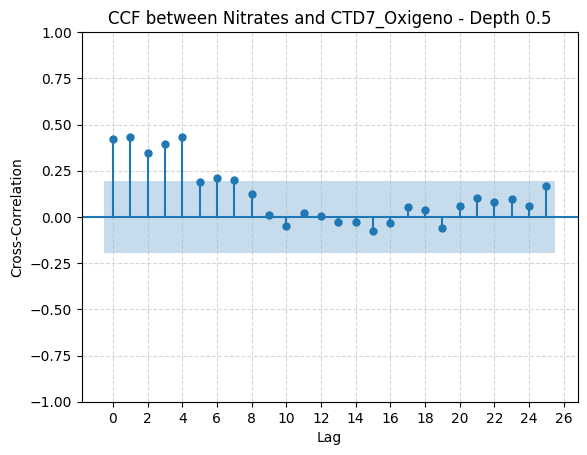

<Figure size 800x400 with 0 Axes>

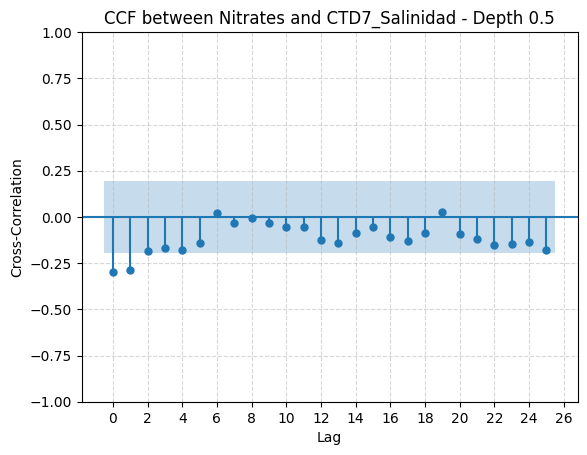

<Figure size 800x400 with 0 Axes>

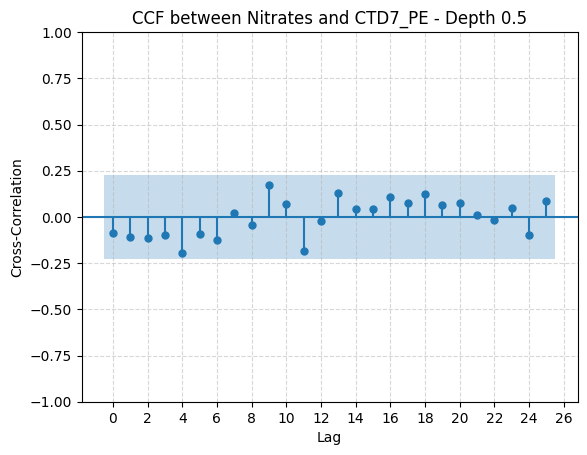

<Figure size 800x400 with 0 Axes>

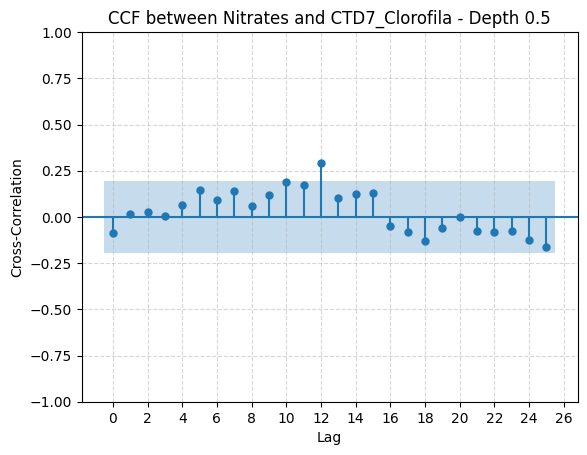

<Figure size 800x400 with 0 Axes>

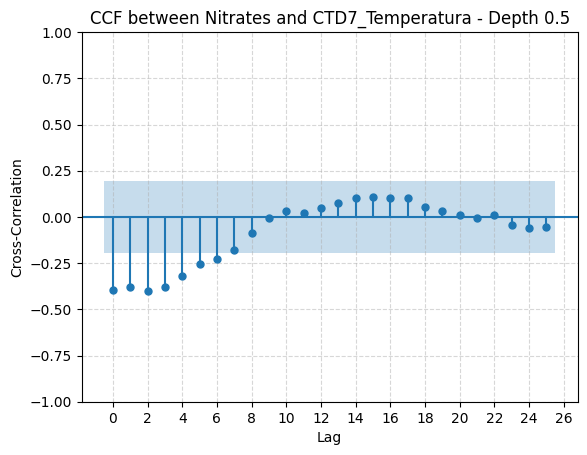

<Figure size 800x400 with 0 Axes>

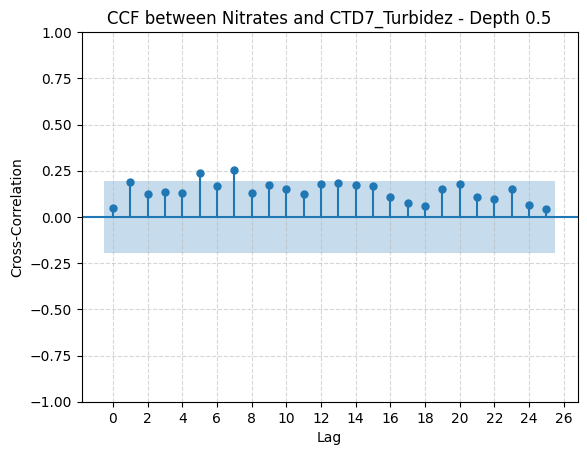

<Figure size 800x400 with 0 Axes>

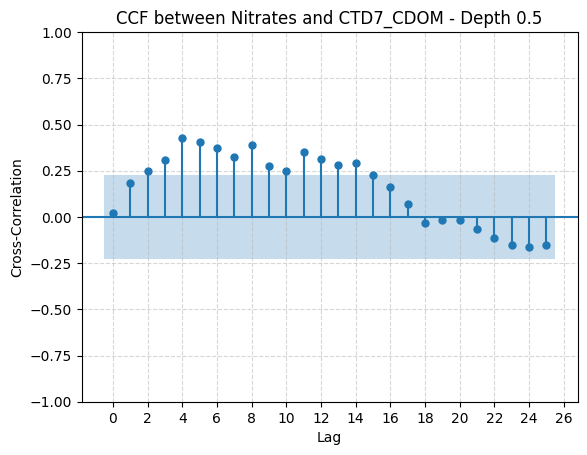

In [246]:
for nombre, df in dataframes_CTD7.items():
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.set_index('Date')
    
    if '0.5' in df.columns:
        # Alinear las series para garantizar que tengan las mismas fechas
        aligned_total, aligned_depth =dataframes_interpolados["Nitratos"].set_index('Fecha')["Nitratos CTD7"].align(df['0.5'], join='inner')
        plt.figure(figsize=(8, 4))
        plot_ccf(aligned_total, aligned_depth, lags=25)  #
        plt.xlabel('Lag')
        plt.ylabel('Cross-Correlation')
        plt.grid(linestyle="--", alpha=0.5)
        plt.xticks(range(0,28,2))
        plt.title(f'CCF between Nitrates and {nombre} - Depth 0.5')
        plt.show()

#### Nitratos diario - CTD7

<Figure size 800x400 with 0 Axes>

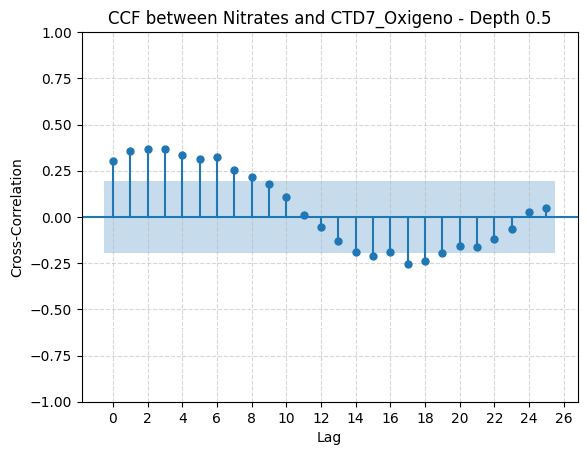

<Figure size 800x400 with 0 Axes>

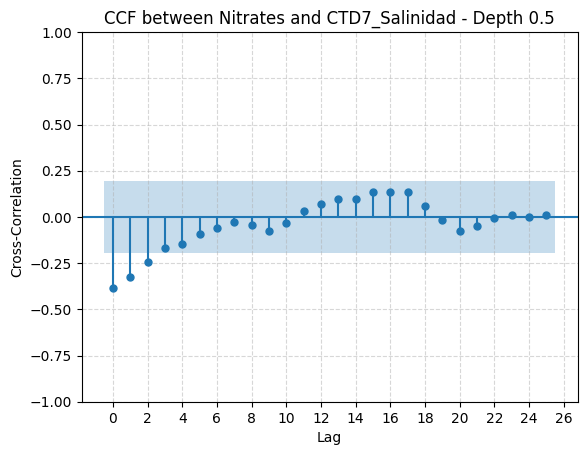

<Figure size 800x400 with 0 Axes>

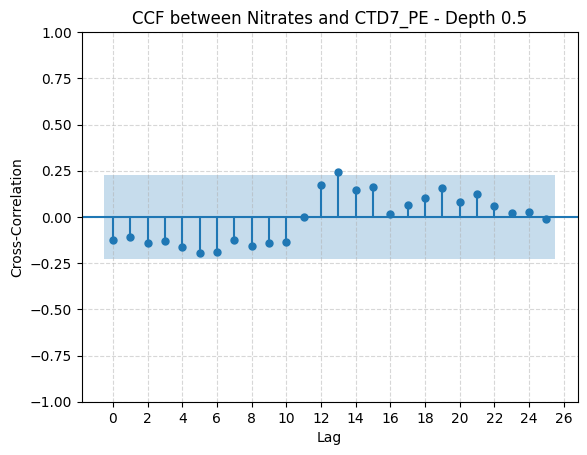

<Figure size 800x400 with 0 Axes>

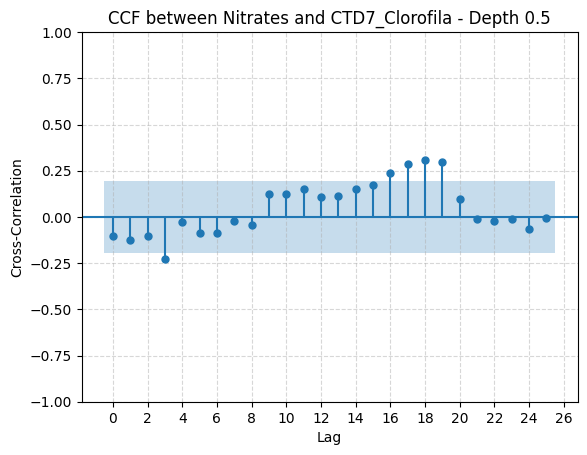

<Figure size 800x400 with 0 Axes>

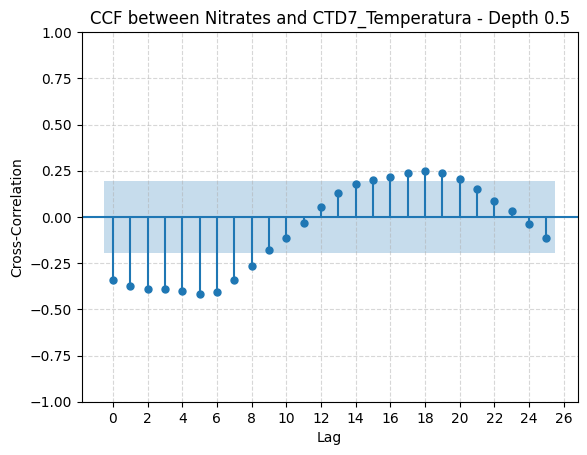

<Figure size 800x400 with 0 Axes>

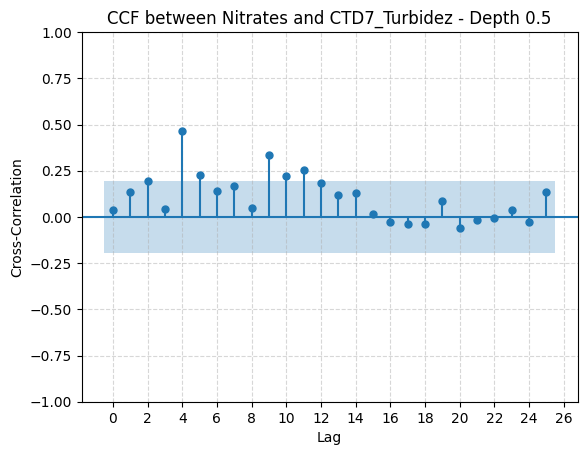

<Figure size 800x400 with 0 Axes>

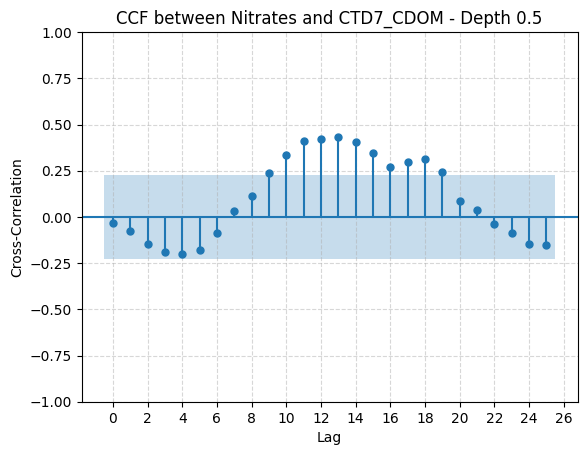

In [320]:
# Nitratos Diario
for nombre, df in dataframes_CTD7.items():
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.set_index('Date')
    
    if '0.5' in df.columns:
        # Alinear las series para garantizar que tengan las mismas fechas
        aligned_total, aligned_depth =dataframes_interpolados["Nitratos Diario"].set_index('Fecha')["Nitratos CTD7"].align(df['0.5'], join='inner')
        plt.figure(figsize=(8, 4))
        plot_ccf(aligned_total, aligned_depth, lags=25)  #
        plt.xlabel('Lag')
        plt.ylabel('Cross-Correlation')
        plt.grid(linestyle="--", alpha=0.5)
        plt.xticks(range(0,28,2))
        plt.title(f'CCF between Nitrates and {nombre} - Depth 0.5')
        plt.show()

#### Fosfatos puntual - CTD7

<Figure size 800x400 with 0 Axes>

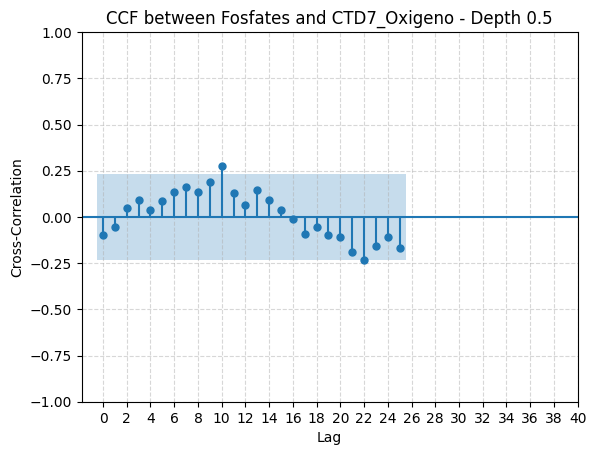

<Figure size 800x400 with 0 Axes>

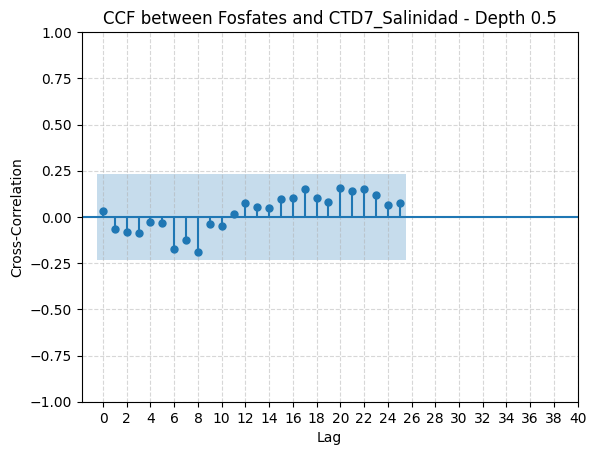

<Figure size 800x400 with 0 Axes>

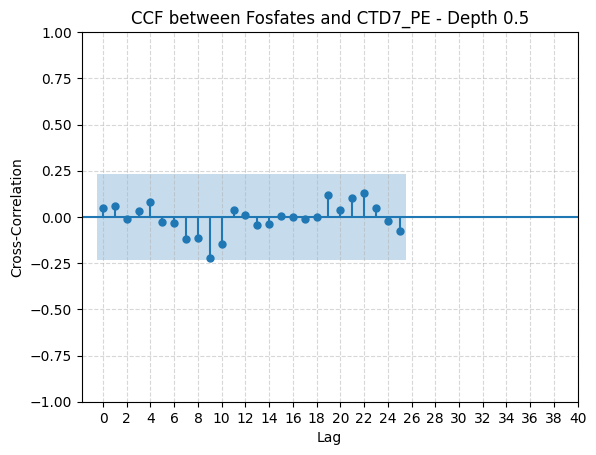

<Figure size 800x400 with 0 Axes>

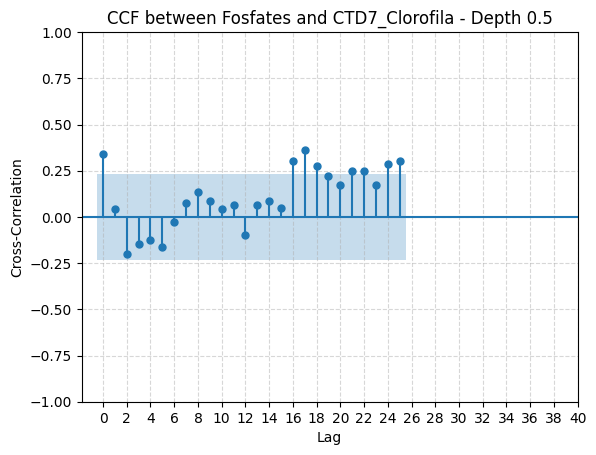

<Figure size 800x400 with 0 Axes>

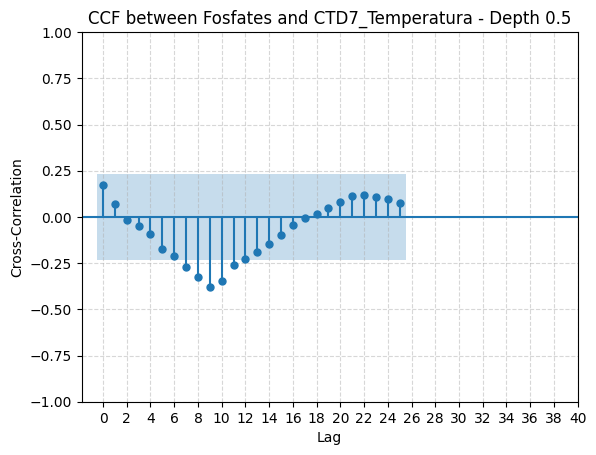

<Figure size 800x400 with 0 Axes>

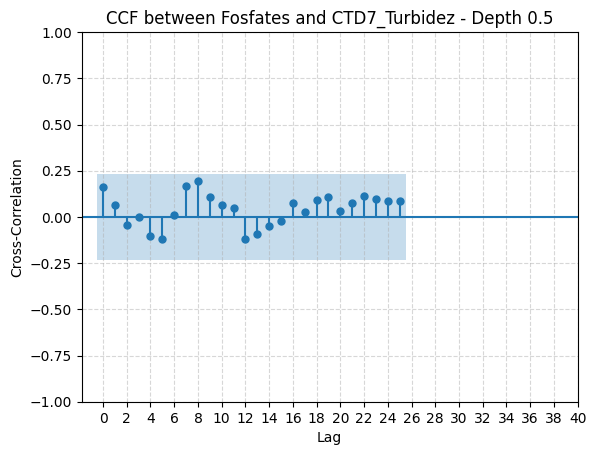

<Figure size 800x400 with 0 Axes>

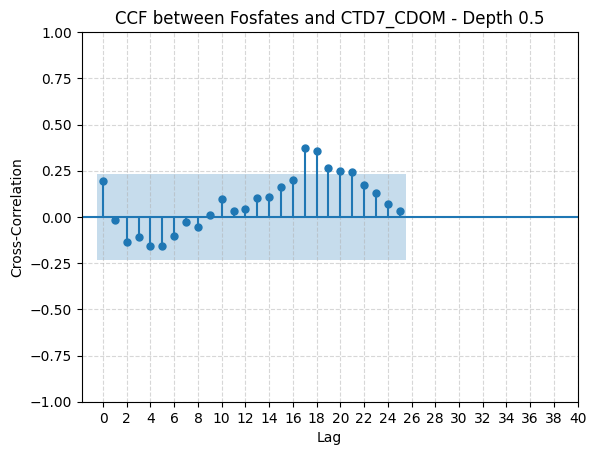

In [243]:
# Fosfatos puntual
for nombre, df in dataframes_CTD7.items():
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.set_index('Date')

    if '0.5' in df.columns:
        # Alinear las series para garantizar que tengan las mismas fechas
        aligned_total, aligned_depth =dataframes_interpolados["Fosfatos"].set_index('Fecha')["Fosfatos CTD7"].align(df['0.5'], join='inner')
        plt.figure(figsize=(8, 4))
        plot_ccf(aligned_total, aligned_depth, lags=25) 
        plt.xlabel('Lag')
        plt.ylabel('Cross-Correlation')
        plt.grid(linestyle="--", alpha=0.5)
        plt.xticks(range(0,42,2))
        plt.title(f'CCF between Fosfates and {nombre} - Depth 0.5')
        plt.show()

#### Fosfatos diario - CTD7

<Figure size 800x400 with 0 Axes>

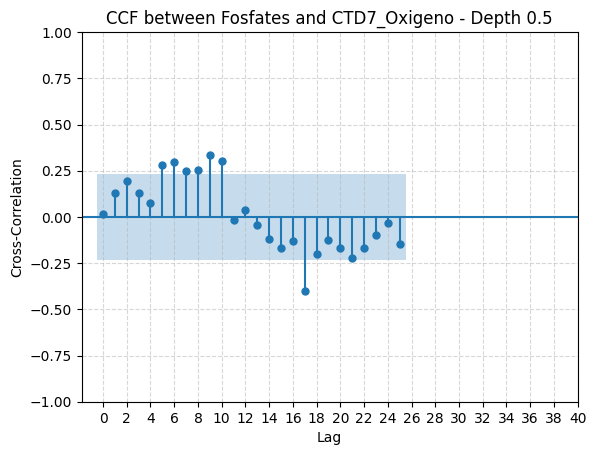

<Figure size 800x400 with 0 Axes>

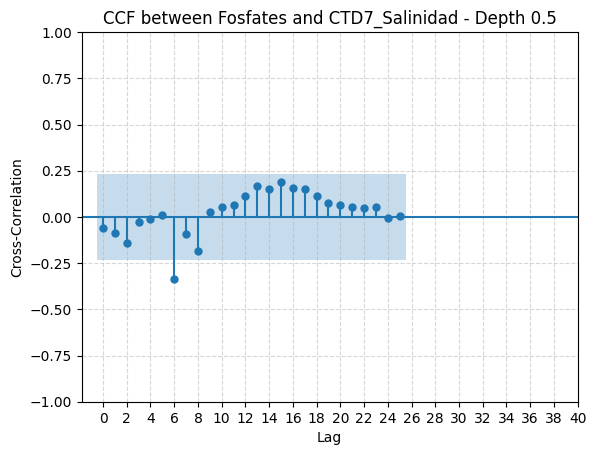

<Figure size 800x400 with 0 Axes>

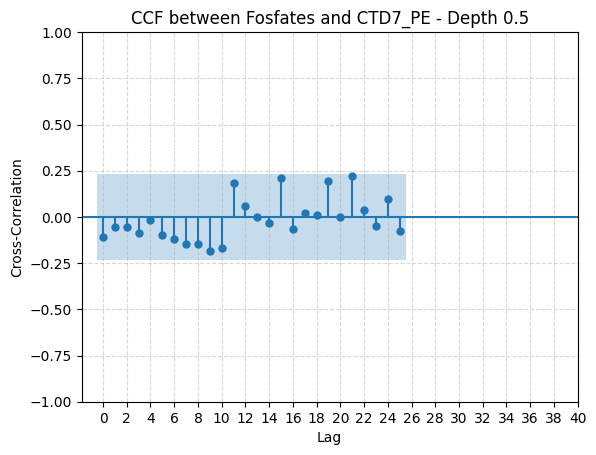

<Figure size 800x400 with 0 Axes>

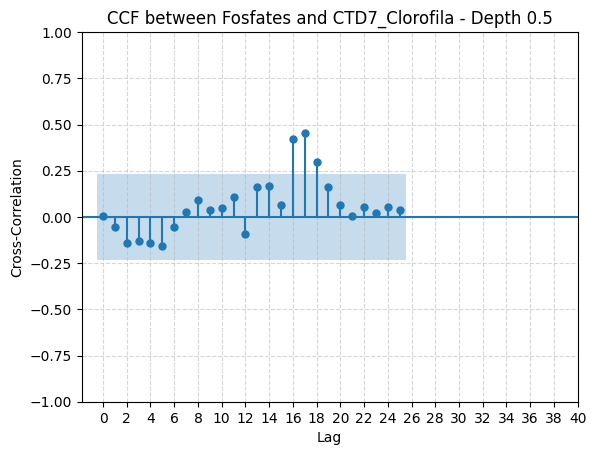

<Figure size 800x400 with 0 Axes>

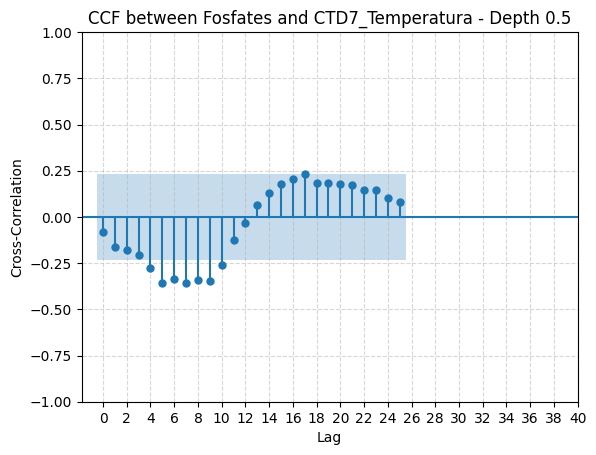

<Figure size 800x400 with 0 Axes>

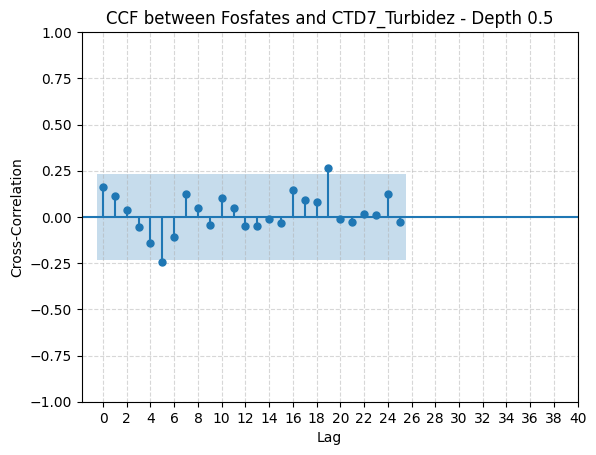

<Figure size 800x400 with 0 Axes>

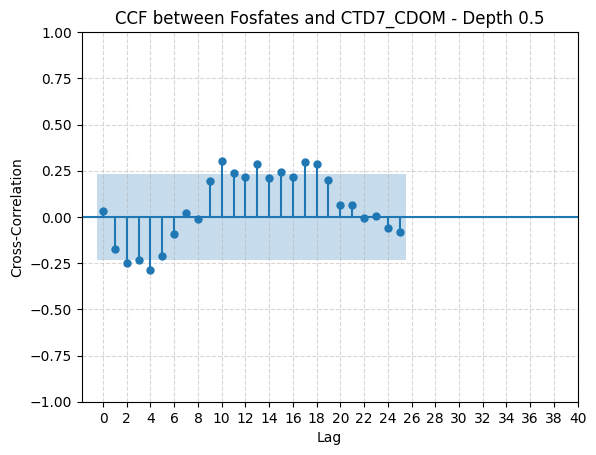

In [321]:
# Fosfatos diario
for nombre, df in dataframes_CTD7.items():
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.set_index('Date')

    if '0.5' in df.columns:
        # Alinear las series para garantizar que tengan las mismas fechas
        aligned_total, aligned_depth =dataframes_interpolados["Fosfatos Diario"].set_index('Fecha')["Fosfatos CTD7"].align(df['0.5'], join='inner')
        plt.figure(figsize=(8, 4))
        plot_ccf(aligned_total, aligned_depth, lags=25) 
        plt.xlabel('Lag')
        plt.ylabel('Cross-Correlation')
        plt.grid(linestyle="--", alpha=0.5)
        plt.xticks(range(0,42,2))
        plt.title(f'CCF between Fosfates and {nombre} - Depth 0.5')
        plt.show()

#### Nitratos puntual - CTD9

<Figure size 800x400 with 0 Axes>

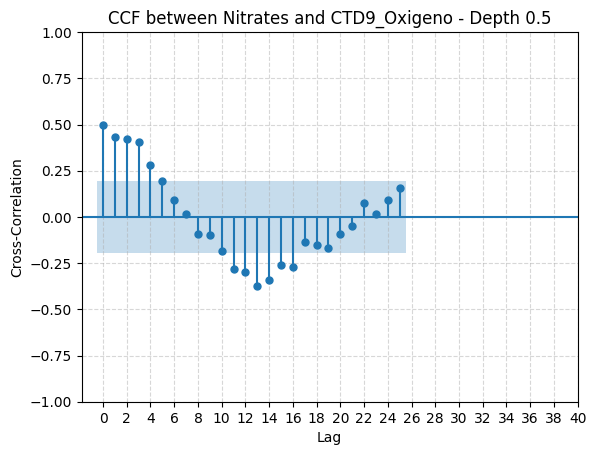

<Figure size 800x400 with 0 Axes>

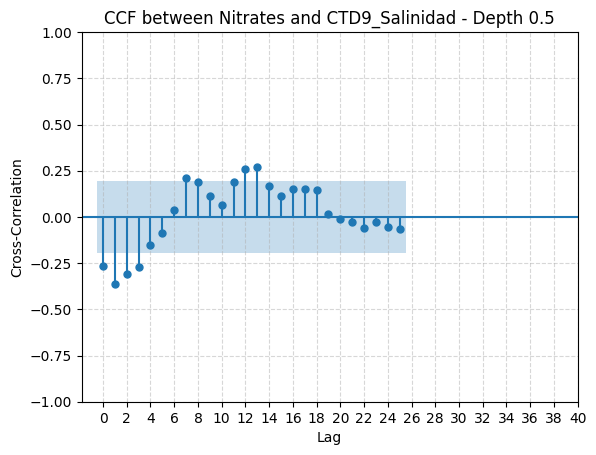

<Figure size 800x400 with 0 Axes>

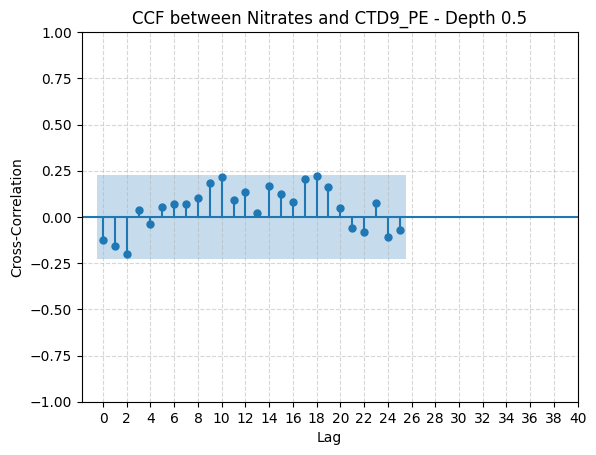

<Figure size 800x400 with 0 Axes>

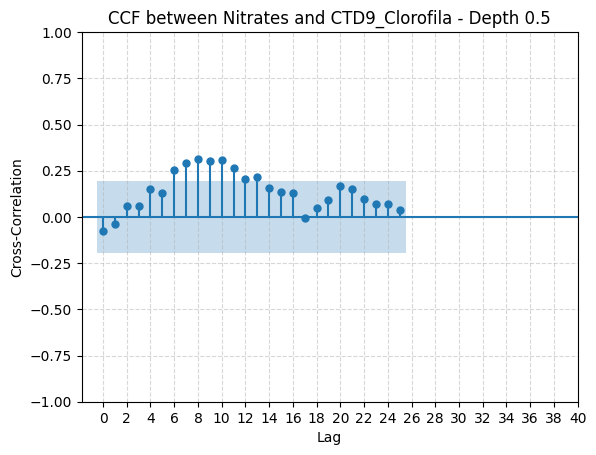

<Figure size 800x400 with 0 Axes>

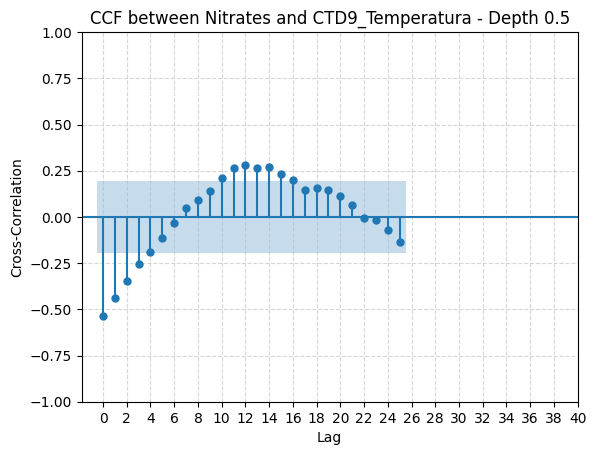

<Figure size 800x400 with 0 Axes>

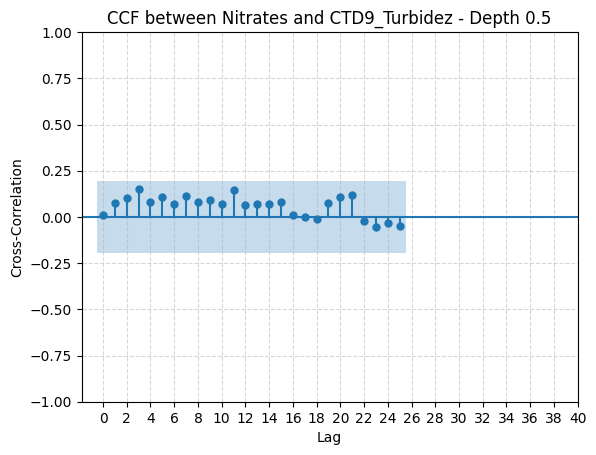

<Figure size 800x400 with 0 Axes>

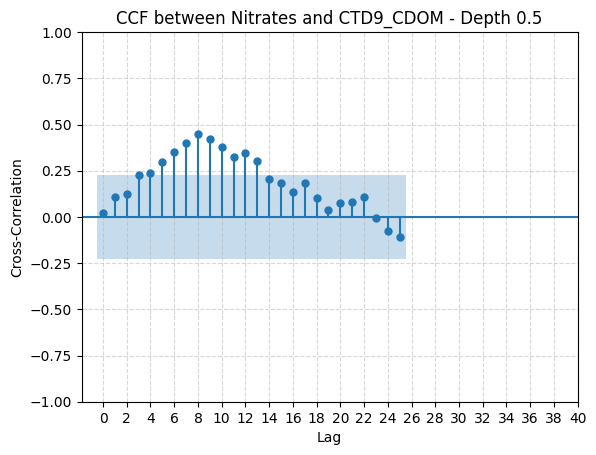

In [244]:
for nombre, df in dataframes_CTD9.items():
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.set_index('Date')

    if '0.5' in df.columns:
        aligned_total, aligned_depth =dataframes_interpolados["Nitratos"].set_index('Fecha')["Nitratos CTD9"].align(df['0.5'], join='inner')
        plt.figure(figsize=(8, 4))
        plot_ccf(aligned_total, aligned_depth, lags=25)  
        plt.xlabel('Lag')
        plt.ylabel('Cross-Correlation')
        plt.grid(linestyle="--", alpha=0.5)
        plt.xticks(range(0,42,2))
        plt.title(f'CCF between Nitrates and {nombre} - Depth 0.5')
        plt.show()

#### Nitratos diario - CTD9

<Figure size 800x400 with 0 Axes>

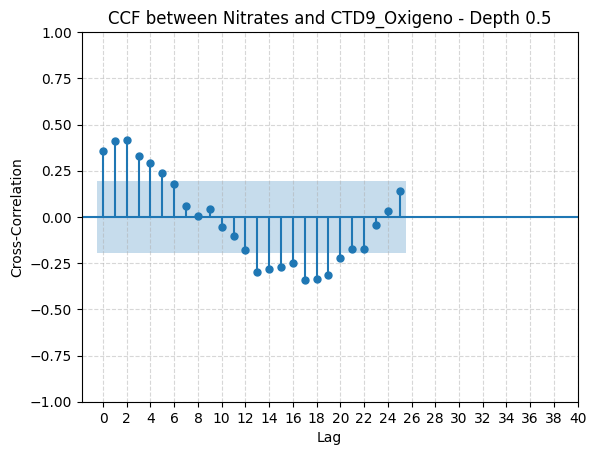

<Figure size 800x400 with 0 Axes>

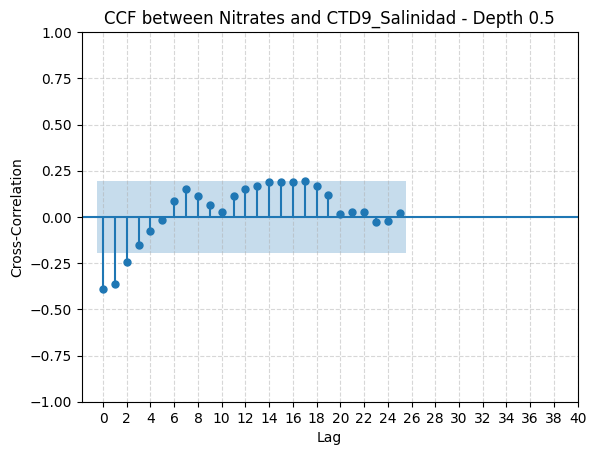

<Figure size 800x400 with 0 Axes>

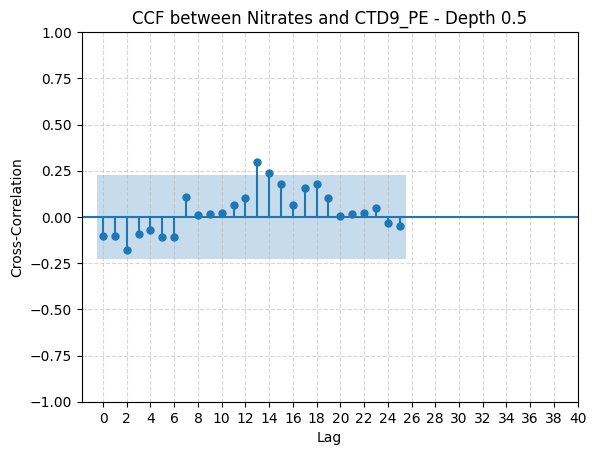

<Figure size 800x400 with 0 Axes>

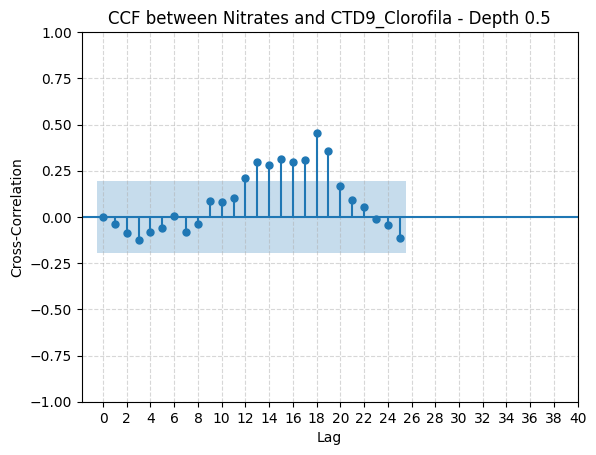

<Figure size 800x400 with 0 Axes>

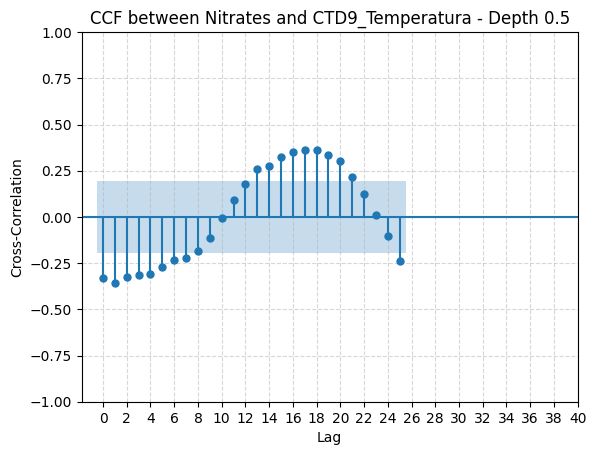

<Figure size 800x400 with 0 Axes>

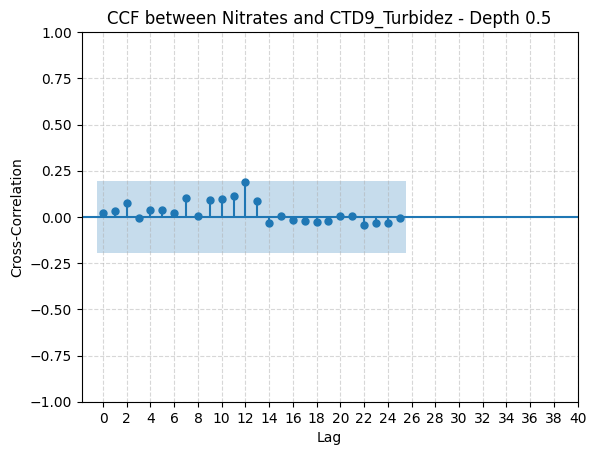

<Figure size 800x400 with 0 Axes>

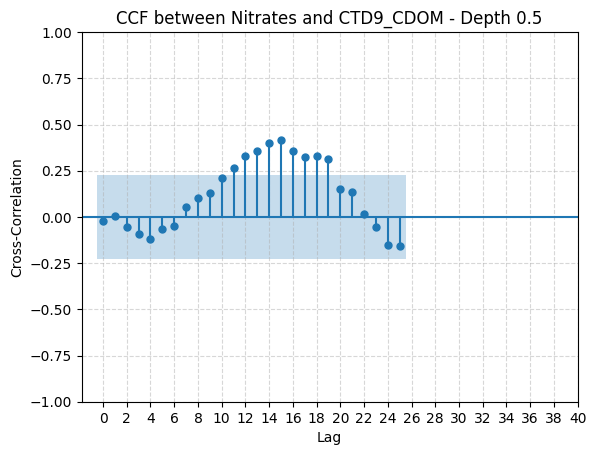

In [322]:

for nombre, df in dataframes_CTD9.items():
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.set_index('Date')

    if '0.5' in df.columns:
        aligned_total, aligned_depth =dataframes_interpolados["Nitratos Diario"].set_index('Fecha')["Nitratos CTD9"].align(df['0.5'], join='inner')
        plt.figure(figsize=(8, 4))
        plot_ccf(aligned_total, aligned_depth, lags=25)  
        plt.xlabel('Lag')
        plt.ylabel('Cross-Correlation')
        plt.grid(linestyle="--", alpha=0.5)
        plt.xticks(range(0,42,2))
        plt.title(f'CCF between Nitrates and {nombre} - Depth 0.5')
        plt.show()

#### Fosfatos puntual - CTD9

<Figure size 800x400 with 0 Axes>

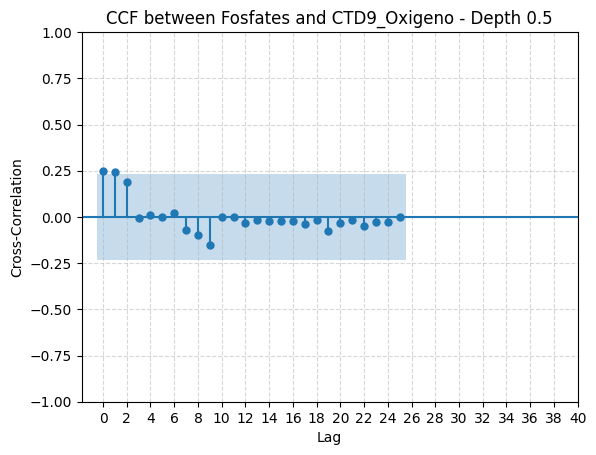

<Figure size 800x400 with 0 Axes>

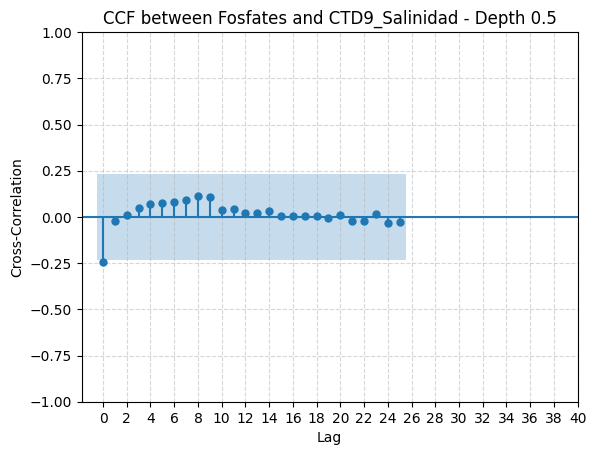

<Figure size 800x400 with 0 Axes>

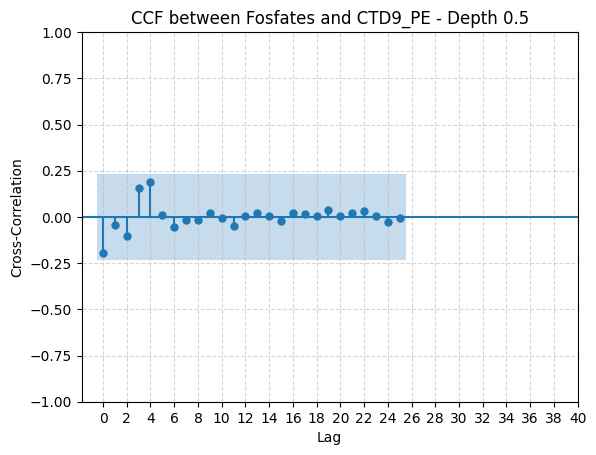

<Figure size 800x400 with 0 Axes>

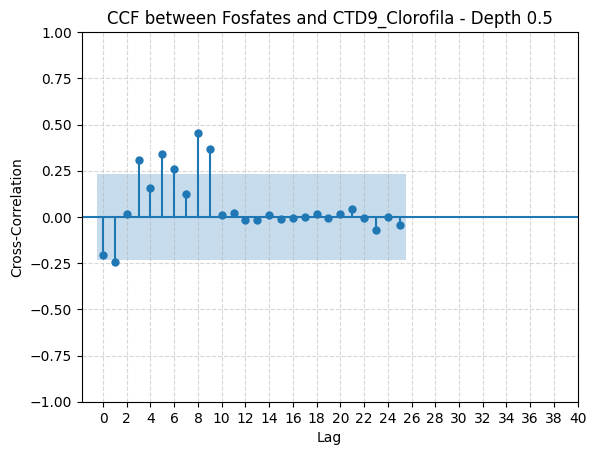

<Figure size 800x400 with 0 Axes>

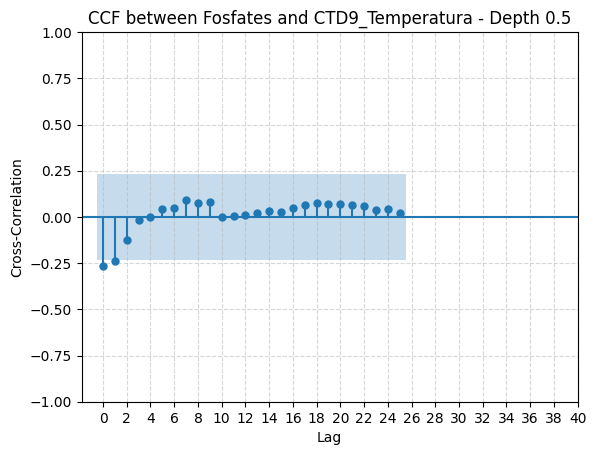

<Figure size 800x400 with 0 Axes>

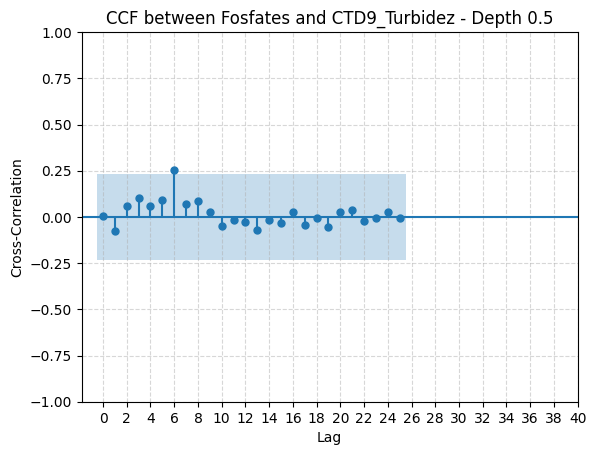

<Figure size 800x400 with 0 Axes>

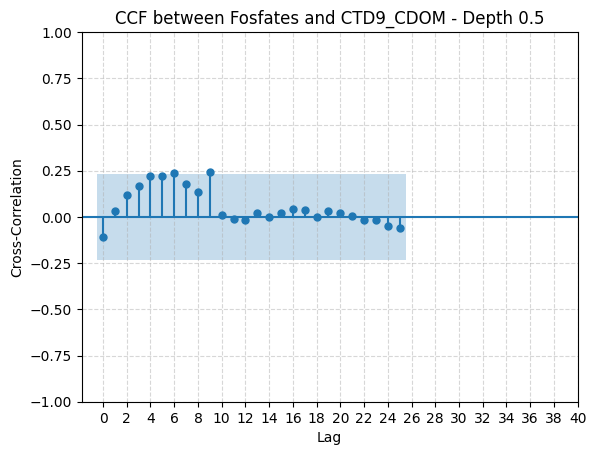

In [326]:
# Fosfatos puntual
for nombre, df in dataframes_CTD9.items():
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.set_index('Date')

    if '0.5' in df.columns:
        # Alinear las series para garantizar que tengan las mismas fechas
        aligned_total, aligned_depth =dataframes_interpolados["Fosfatos"].set_index('Fecha')["Fosfatos CTD9"].align(df['0.5'], join='inner')
        plt.figure(figsize=(8, 4))
        plot_ccf(aligned_total, aligned_depth, lags=25) 
        plt.xlabel('Lag')
        plt.ylabel('Cross-Correlation')
        plt.grid(linestyle="--", alpha=0.5)
        plt.xticks(range(0,42,2))
        plt.title(f'CCF between Fosfates and {nombre} - Depth 0.5')
        plt.show()

#### Fosfatos diario - CTD9

<Figure size 800x400 with 0 Axes>

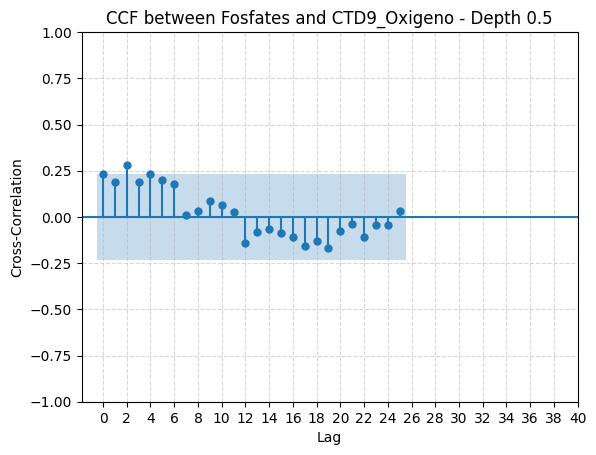

<Figure size 800x400 with 0 Axes>

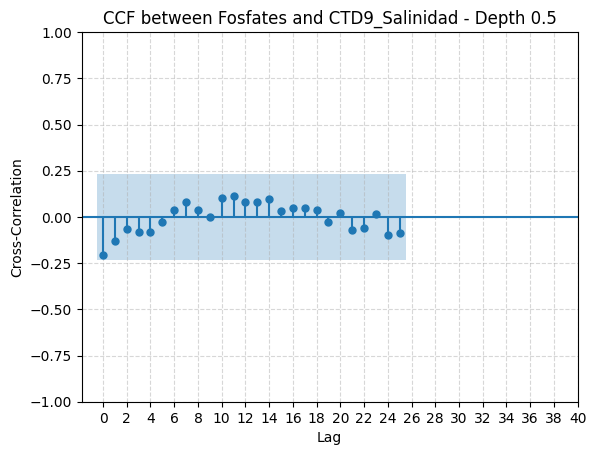

<Figure size 800x400 with 0 Axes>

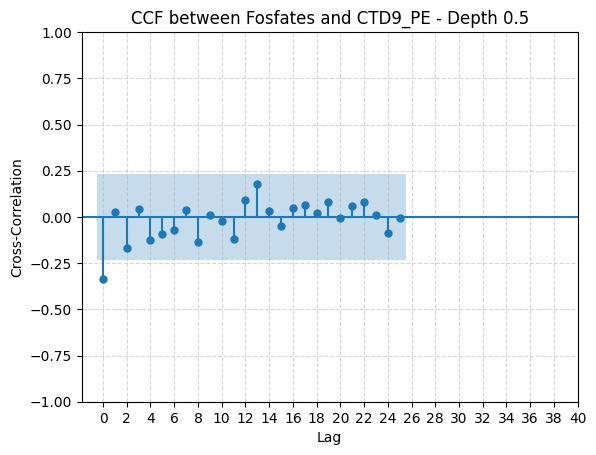

<Figure size 800x400 with 0 Axes>

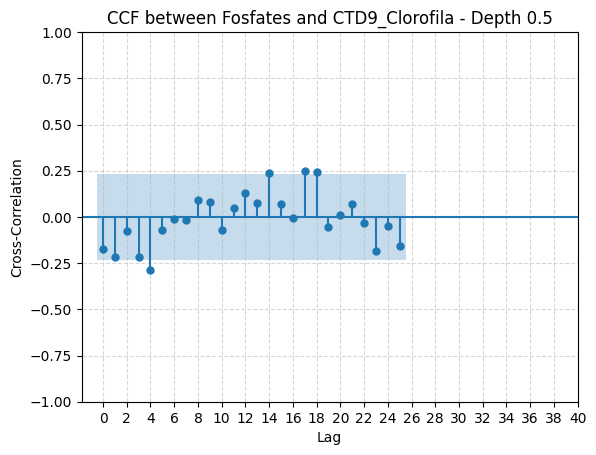

<Figure size 800x400 with 0 Axes>

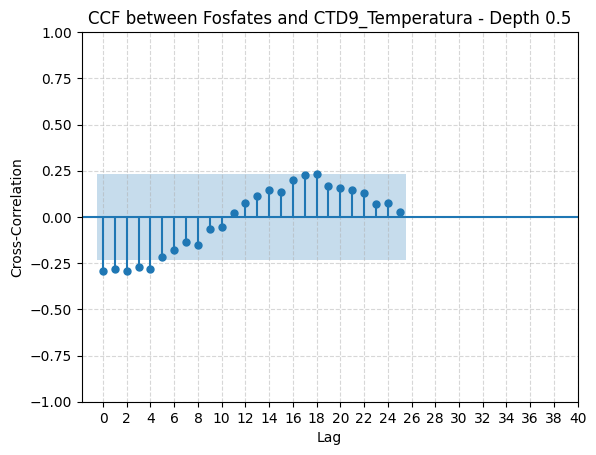

<Figure size 800x400 with 0 Axes>

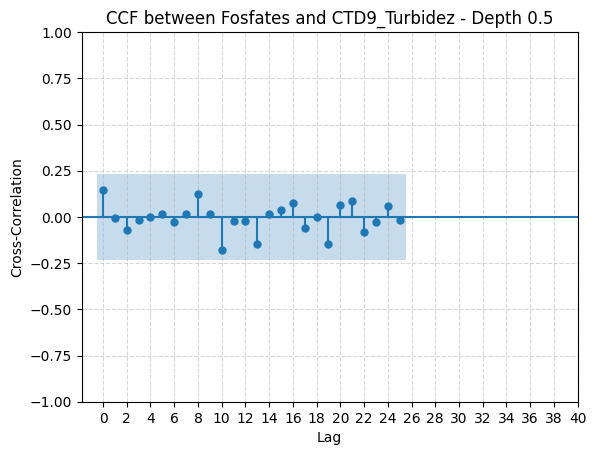

<Figure size 800x400 with 0 Axes>

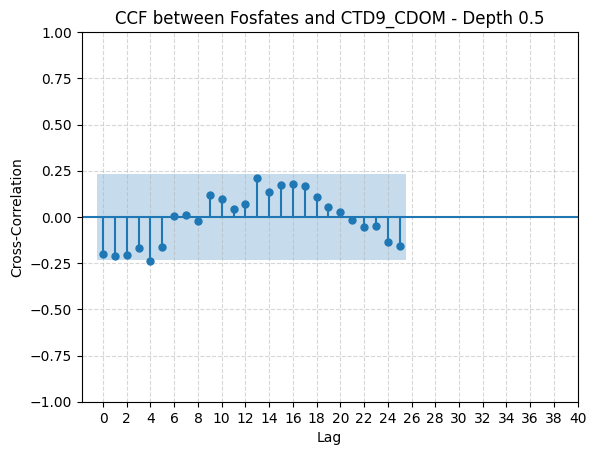

In [327]:
# Fosfatos diario
for nombre, df in dataframes_CTD9.items():
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.set_index('Date')

    if '0.5' in df.columns:
        # Alinear las series para garantizar que tengan las mismas fechas
        aligned_total, aligned_depth =dataframes_interpolados["Fosfatos Diario"].set_index('Fecha')["Fosfatos CTD9"].align(df['0.5'], join='inner')
        plt.figure(figsize=(8, 4))
        plot_ccf(aligned_total, aligned_depth, lags=25) 
        plt.xlabel('Lag')
        plt.ylabel('Cross-Correlation')
        plt.grid(linestyle="--", alpha=0.5)
        plt.xticks(range(0,42,2))
        plt.title(f'CCF between Fosfates and {nombre} - Depth 0.5')
        plt.show()

### Reconstruir serie temporal completa

In [331]:
dataframes_interpolados["Caudal"]

,Fecha,Desembocadura rambla Albujón,Obra de paso bajo carretera Los Urrutia,Rambla de las Matildes - corriente sur,Lo Poyo
1,2019-08-30,212.381526,50.751889,21.194880,11.527840
2,2019-09-06,220.645922,49.737364,17.740978,11.742434
3,2019-09-20,208.364671,49.478034,14.691326,11.465259
4,2019-09-26,209.480486,47.860915,14.988545,12.067444
5,2019-10-02,211.160368,93.010294,13.872670,13.103672
...,...,...,...,...,...
463,2024-03-13,121.560000,43.566364,2.120000,2.560000
464,2024-03-15,131.480000,43.566364,2.260000,2.180000
465,2024-03-20,127.240000,43.566365,2.520000,2.200000
466,2024-03-22,138.490000,43.566365,2.240000,3.000000


In [340]:
dataframes_interpolados["Nitratos Diario"].set_index('Fecha').resample('D').asfreq()

ValueError: cannot reindex on an axis with duplicate labels

In [333]:
dataframes_marmenor = dataframes_interpolados.copy()
# Assuming your dictionary of dataframes is called `dataframes_dict`
for name, df in dataframes_marmenor.items():
    df = df.set_index('Fecha')
    df = df.resample('D').asfreq()
    df = df.interpolate(method='linear')
    df.reset_index(inplace=True)
    dataframes_marmenor[name] = df

ValueError: cannot reindex on an axis with duplicate labels